In [1]:
!pip install segmentation-models-pytorch==0.3.3 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.6 MB/s eta 0:00:00


In [2]:
import sys
import os
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
# ==============================================================================
# THÊM VÀO ĐẦU FILE 04/05/08
# LOAD PREPROCESSING UTILS TỪ CHECKPOINT
# ==============================================================================

import os
import json
import cv2
import numpy as np

# Mount drive

GDRIVE_PATH = "d:/DoAn_DaLieu"

print("="*80)
print("📦 LOADING PREPROCESSING UTILS FROM CHECKPOINT")
print("="*80)

# ------------------------------------------------------------------------------
# BƯỚC 1: LOAD CHECKPOINT
# ------------------------------------------------------------------------------

checkpoint_path = os.path.join(GDRIVE_PATH, "3_Checkpoints", "10_preprocessing_utils_complete.json")

if not os.path.exists(checkpoint_path):
    print(f"❌ Checkpoint not found: {checkpoint_path}")
    print("⚠️  Please run File 10 first!")
    raise FileNotFoundError(checkpoint_path)

with open(checkpoint_path, 'r', encoding='utf-8') as f:
    prep_config = json.load(f)

print(f"✅ Checkpoint loaded:   {prep_config['timestamp']}")
print(f"   Version: {prep_config['version']}")

# ------------------------------------------------------------------------------
# BƯỚC 2: ĐỊNH NGHĨA CLASSES (Compact version)
# ------------------------------------------------------------------------------

class PreprocessingPipeline:
    """Pipeline tiền xử lý cho ảnh da xấu"""
    def __init__(self, remove_hair=True, reduce_shadow=True, smooth_skin=True, enhance_contrast=False):
        self.remove_hair = remove_hair
        self.reduce_shadow = reduce_shadow
        self.smooth_skin = smooth_skin
        self.enhance_contrast = enhance_contrast

    def __call__(self, image):
        debug_info = {'original':   image.copy()}
        processed = image.copy()
        if self.remove_hair:
            processed = self._remove_hair(processed)
            debug_info['after_hair_removal'] = processed.copy()
        if self.reduce_shadow:
            processed = self._reduce_shadow(processed)
            debug_info['after_shadow_reduction'] = processed.copy()
        if self.smooth_skin:
            processed = self._smooth_skin(processed)
            debug_info['after_smoothing'] = processed.copy()
        if self.enhance_contrast:
            processed = self._enhance_contrast(processed)
            debug_info['after_contrast'] = processed.copy()
        return processed, debug_info

    def _remove_hair(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
        _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
        if np.sum(hair_mask > 0) > 100:
            return cv2.inpaint(image, hair_mask, inpaintRadius=6, flags=cv2.INPAINT_TELEA)
        return image

    def _reduce_shadow(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge([l_clahe, a, b])
        return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    def _smooth_skin(self, image):
        return cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

    def _enhance_contrast(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge([l_clahe, a, b])
        return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)


class PostprocessingPipeline:
    """Pipeline hậu xử lý cho mask"""
    def __init__(self, fill_holes=True, remove_small_objects=True, smooth_boundary=True, select_largest=True, min_object_size=500, smart_mode=True,  # ← THÊM
                 distance_threshold=30):  # ← THÊM):
        self.fill_holes = fill_holes
        self.remove_small_objects = remove_small_objects
        self.smooth_boundary = smooth_boundary
        self.select_largest = select_largest
        self.min_object_size = min_object_size

    def __call__(self, mask_pred, threshold=0.5):
        debug_info = {'original':  mask_pred.copy(), 'warnings': []}  # ← THÊM warnings
        mask_binary = (mask_pred > threshold).astype(np.uint8) * 255
        debug_info['binary'] = mask_binary.copy()
        processed = mask_binary.copy()

        if self.fill_holes:
            processed = self._fill_holes(processed)
            debug_info['filled'] = processed.copy()
        if self.remove_small_objects:
            processed = self._remove_small(processed, self.min_object_size)
            debug_info['cleaned'] = processed.copy()
        if self.smooth_boundary:
            processed = self._smooth_boundary(processed)
            debug_info['smoothed'] = processed.copy()
        if self.select_largest:
            processed, best_contour = self._select_largest(processed)
            debug_info['largest'] = processed.copy()
            debug_info['best_contour'] = best_contour

        return processed, debug_info

    def _fill_holes(self, mask):
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
        closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        h, w = closed.shape
        mask_flood = closed.copy()
        cv2.floodFill(mask_flood, None, (0, 0), 255)
        mask_flood_inv = cv2.bitwise_not(mask_flood)
        return closed | mask_flood_inv

    def _remove_small(self, mask, min_size):
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        cleaned = np.zeros_like(mask)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= min_size:
                cleaned[labels == i] = 255
        return cleaned

    def _smooth_boundary(self, mask):
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        smoothed = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        smoothed = cv2.morphologyEx(smoothed, cv2.MORPH_CLOSE, kernel)
        return smoothed

    def _select_largest(self, mask):
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) == 0:
            return mask, None
        contour_features = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < self.min_object_size:
                continue
            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            solidity = area / hull_area if hull_area > 0 else 0
            score = area * (0.8 + 0.2 * solidity)
            contour_features.append({'contour': cnt, 'score': score})
        if not contour_features:
            return mask, None
        best = max(contour_features, key=lambda x: x['score'])
        mask_largest = np.zeros_like(mask)
        cv2.drawContours(mask_largest, [best['contour']], -1, 255, -1)
        return mask_largest, best['contour']

# ------------------------------------------------------------------------------
# BƯỚC 3: HELPER FUNCTIONS (Dùng config từ checkpoint)
# ------------------------------------------------------------------------------

PREPROCESSING_PRESETS = prep_config['preprocessing']['presets']
POSTPROCESSING_PRESETS = prep_config['postprocessing']['presets']

def get_preprocessing_preset(preset_name):
    """Tạo PreprocessingPipeline từ preset name"""
    if preset_name not in PREPROCESSING_PRESETS:
        raise ValueError(f"Unknown preset: {preset_name}.Available: {list(PREPROCESSING_PRESETS.keys())}")
    return PreprocessingPipeline(**PREPROCESSING_PRESETS[preset_name]['config'])

def get_postprocessing_preset(preset_name):
    """Tạo PostprocessingPipeline từ preset name"""
    if preset_name not in POSTPROCESSING_PRESETS:
        raise ValueError(f"Unknown preset: {preset_name}.Available: {list(POSTPROCESSING_PRESETS.keys())}")
    return PostprocessingPipeline(**POSTPROCESSING_PRESETS[preset_name]['config'])

print("✅ Classes & helpers defined")
print(f"   - Preprocessing presets: {list(PREPROCESSING_PRESETS.keys())}")
print(f"   - Postprocessing presets: {list(POSTPROCESSING_PRESETS.keys())}")

print("\n" + "="*80)

Mounted at /content/drive
📦 LOADING PREPROCESSING UTILS FROM CHECKPOINT
✅ Checkpoint loaded:   2026-03-28T02:39:10.082208
   Version: 1.1.0
✅ Classes & helpers defined
   - Preprocessing presets: ['smartphone', 'smartphone_light', 'elderly_skin', 'clinic', 'clean']
   - Postprocessing presets: ['noisy', 'clean']



In [3]:
import sys
import os
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
# ==============================================================================
# Ô CODE 1: IMPORT VÀ SETUP
# ==============================================================================
print("="*80)
print("🔬 BƯỚC 5: TRÍCH XUẤT ROI TỪ SEGMENTATION")
print("="*80)

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, json, cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader


GDRIVE_PATH = "d:/DoAn_DaLieu"
PROCESSED_DATA_PATH = os.path.join(GDRIVE_PATH, "1_Data/processed")
CHECKPOINT_PATH = os.path.join(GDRIVE_PATH, "3_Checkpoints")
MODEL_PATH = os.path.join(GDRIVE_PATH, "4_Models")
ROI_OUTPUT_PATH = os.path.join(PROCESSED_DATA_PATH, "roi_data")

os.makedirs(ROI_OUTPUT_PATH, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Device: {device}")

🔬 BƯỚC 5: TRÍCH XUẤT ROI TỪ SEGMENTATION

🖥️ Device: cpu


In [4]:
# ==============================================================================
# Ô CODE 2: LOAD BEST SEGMENTATION MODEL FROM CHECKPOINT (FIXED)
# ==============================================================================
print("\n" + "="*80)
print("📦 LOAD BEST SEGMENTATION MODEL")
print("="*80)

# Load checkpoint từ File 04
hybrid_checkpoint_file = os.path.join(CHECKPOINT_PATH, "04_hybrid_complete.json")

if not os.path.exists(hybrid_checkpoint_file):
    raise FileNotFoundError("❌ Chưa chạy File 04! Cần có checkpoint.")

with open(hybrid_checkpoint_file, 'r') as f:
    hybrid_info = json.load(f)

# ✅ FIX: Get best model from checkpoint
best_model_name = hybrid_info['model_selection']['best_model_name']
print(f"✅ Best model from File 04: {best_model_name}")
print(f"   Reason: {hybrid_info['model_selection']['reason']}")
print(f"   Score: {hybrid_info['model_selection']['reasoning']['weighted_score']:.4f}")

# Load pretrained models
unet_checkpoint_file = os.path.join(CHECKPOINT_PATH, "02_unet_complete.json")
deeplab_checkpoint_file = os.path.join(CHECKPOINT_PATH, "03_deeplabv3plus_complete.json")

with open(unet_checkpoint_file, 'r') as f:
    unet_model_path = json.load(f)['paths']['best_model']

with open(deeplab_checkpoint_file, 'r') as f:
    deeplab_model_path = json.load(f)['paths']['best_model']

# Load U-Net
unet_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
unet_model.load_state_dict(torch.load(unet_model_path, map_location=device)['model_state_dict'])
unet_model = unet_model.to(device)
unet_model.eval()

# Load DeepLabV3+
deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
deeplab_model.load_state_dict(torch.load(deeplab_model_path, map_location=device)['model_state_dict'])
deeplab_model = deeplab_model.to(device)
deeplab_model.eval()

print("✅ Loaded both models")


📦 LOAD BEST SEGMENTATION MODEL
✅ Best model from File 04: DeepLabV3+
   Reason: Highest weighted score (0.6936)
   Score: 0.6936
Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 269MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 253MB/s]


✅ Loaded both models


In [5]:
# ==============================================================================
# Ô CODE 3: SELECT SEGMENTATION MODEL (FIXED)
# ==============================================================================

# ✅ FIX: Select model based on checkpoint
if best_model_name == 'DeepLabV3+':
    segmentation_model = deeplab_model
    print(f"\n✅ Using {best_model_name} for ROI extraction")
elif best_model_name == 'U-Net':
    segmentation_model = unet_model
    print(f"\n✅ Using {best_model_name} for ROI extraction")
else:
    # Fallback
    segmentation_model = deeplab_model
    print(f"\n⚠️ Unknown model '{best_model_name}', using DeepLabV3+ as default")

segmentation_model.eval()
print(f"✅ Model ready for segmentation")


✅ Using DeepLabV3+ for ROI extraction
✅ Model ready for segmentation


In [6]:
# ==============================================================================
# Ô CODE 4: LOAD CLASSIFICATION DATA
# ==============================================================================
print("\n" + "="*80)
print("📂 LOAD CLASSIFICATION DATA")
print("="*80)

CLS_DATA_PATH = os.path.join(PROCESSED_DATA_PATH, "classification_data")

train_df = pd.read_csv(os.path.join(CLS_DATA_PATH, "train.csv"))
val_df = pd.read_csv(os.path.join(CLS_DATA_PATH, "val.csv"))
test_df = pd.read_csv(os.path.join(CLS_DATA_PATH, "test.csv"))

print(f"✅ Loaded classification CSV:")
print(f"   - Train: {len(train_df)} samples")
print(f"   - Val: {len(val_df)} samples")
print(f"   - Test: {len(test_df)} samples")


📂 LOAD CLASSIFICATION DATA
✅ Loaded classification CSV:
   - Train: 14020 samples
   - Val: 3004 samples
   - Test: 3006 samples


In [7]:
# ==============================================================================
# Ô CODE 5: ROI EXTRACTION FUNCTION
# ==============================================================================
print("\n" + "="*80)
print("🔍 ĐỊNH NGHĨA ROI EXTRACTION")
print("="*80)

def extract_roi(image, mask, padding=10, target_size=(224, 224)):
    """
    Trích xuất ROI từ ảnh dựa trên mask

    Args:
        image: numpy array (H, W, 3)
        mask: numpy array (H, W), giá trị 0-1
        padding: số pixel padding xung quanh ROI
        target_size: kích thước output

    Returns:
        roi_image: numpy array (target_size[0], target_size[1], 3)
        bbox: (x1, y1, x2, y2)
    """
    # Binarize mask
    mask_binary = (mask > 0.5).astype(np.uint8)

    # Tìm contours
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        # Không tìm thấy ROI → trả về toàn bộ ảnh
        roi = cv2.resize(image, target_size)
        return roi, (0, 0, image.shape[1], image.shape[0])

    # Lấy contour lớn nhất
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Thêm padding
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(image.shape[1], x + w + padding)
    y2 = min(image.shape[0], y + h + padding)

    # Crop ROI
    roi = image[y1:y2, x1:x2]

    # Resize về target_size
    roi_resized = cv2.resize(roi, target_size)

    return roi_resized, (x1, y1, x2, y2)

print("✅ Đã định nghĩa extract_roi()")


🔍 ĐỊNH NGHĨA ROI EXTRACTION
✅ Đã định nghĩa extract_roi()



🚀 BẮT ĐẦU TRÍCH XUẤT ROI
✅ Quality thresholds validated (including overlapping detection)
✅ QualityAssessmentConfig defined (FIX BUG #15 - COMPLETE)
✅ SmartAdaptiveQualityConfig defined (FIX BUG #19 - RECOMMENDED)
✅ detect_overlapping_lesions() defined (FIX BUG #15 - PARAMETERIZED)
✅ estimate_image_quality() defined (FIX BUG #15)
✅ estimate_mask_quality() updated with overlapping detection (FIX BUG #15)
✅ ROIPathManager defined (FIX BUG #18)
✅ path_manager instance created
✅ process_and_save_roi_adaptive() defined (FIX BUG #12, #13, #15, #18) - SINGLE COMPLETE FUNCTION

🤖 ADAPTIVE ROI EXTRACTION
Logic:
  1. Đánh giá chất lượng ảnh (hair, shadow, blur, noise)
  2. Inference baseline
  3. Đánh giá chất lượng mask
  4. Quyết định:
     - Ảnh TỐT + Mask TỐT → Baseline
     - Ảnh TRUNG BÌNH → Light preprocessing (clinic/elderly_skin)
     - Ảnh XẤU → Full preprocessing (smartphone)
  5. Extract ROI

🤖 ADAPTIVE ROI EXTRACTION (Using: DeepLabV3+)
Logic:
  1. Đánh giá chất lượng ảnh (hair, sh

train: 100%|██████████| 14020/14020 [3:33:26<00:00,  1.09it/s]



4️⃣ SAVING RESULTS...
   ✅ CSV: d:/DoAn_DaLieu/1_Data/processed/roi_data/train/train.csv
   ✅ ROI files: 12784/14020

5️⃣ STATISTICS:
   • Total: 14020
   • Baseline:    4 (  0.0%)
   • Light:    12780 ( 91.2%)
   • Full:        0 (  0.0%)
   • Errors:   1236 (  8.8%)

   ⚠️ OVERLAPPING LESION DETECTION:
   • Overlapping:   34 (  0.2%)
     → May need dermoscopy or biopsy for detailed evaluation

📋 PROCESSING VAL (FIX BUG #12, #13, #15, #18)

1️⃣ CHECKING CACHE...
   ❌ Cache incomplete: Missing ROI files (3773/3004)

2️⃣ CACHE DECISION...
   🔄 Cache incomplete, re-processing...

3️⃣ PROCESSING 3004 SAMPLES...


val: 100%|██████████| 3004/3004 [41:34<00:00,  1.20it/s]



4️⃣ SAVING RESULTS...
   ✅ CSV: d:/DoAn_DaLieu/1_Data/processed/roi_data/val/val.csv
   ✅ ROI files: 2734/3004

5️⃣ STATISTICS:
   • Total: 3004
   • Baseline:    0 (  0.0%)
   • Light:    2734 ( 91.0%)
   • Full:        0 (  0.0%)
   • Errors:    270 (  9.0%)

📋 PROCESSING TEST (FIX BUG #12, #13, #15, #18)

1️⃣ CHECKING CACHE...
   ❌ Cache incomplete: Missing ROI files (3791/3006)

2️⃣ CACHE DECISION...
   🔄 Cache incomplete, re-processing...

3️⃣ PROCESSING 3006 SAMPLES...


test: 100%|██████████| 3006/3006 [40:10<00:00,  1.25it/s]



4️⃣ SAVING RESULTS...
   ✅ CSV: d:/DoAn_DaLieu/1_Data/processed/roi_data/test/test.csv
   ✅ ROI files: 2766/3006

5️⃣ STATISTICS:
   • Total: 3006
   • Baseline:    0 (  0.0%)
   • Light:    2766 ( 92.0%)
   • Full:        0 (  0.0%)
   • Errors:    240 (  8.0%)

✅ Hoàn tất ADAPTIVE ROI extraction!
   Đã lưu vào:  d:/DoAn_DaLieu/1_Data/processed/roi_data

🔬 QUALITY CALIBRATION - FIX BUG #19 (Smart Adaptive Thresholds)

📊 Total samples: 20030
   Samples with ROI: 20030

📊 Image Quality Statistics:
   Samples: 18284
   Mean: 0.3698
   Std:  0.0705
   Min:  0.2013
   Max:  0.7042

✅ CALIBRATED THRESHOLDS (Smart Adaptive - FIX BUG #19):
   Baseline: >= 0.4544
   Light:    >= 0.3204
   Full:     <  0.3204

   Distribution:
   Baseline:   9.3%
   Light:     68.6%
   Full:      22.0%

   ✅ Good distribution (9.3% baseline)

   Distribution Analysis:
   Skewness: 0.634
   Is normal-like: False

📊 OVERALL STATISTICS

Train:
  - light     : 12780 ( 91.2%)
  - ERROR     : 1236 (  8.8%)
  - none 

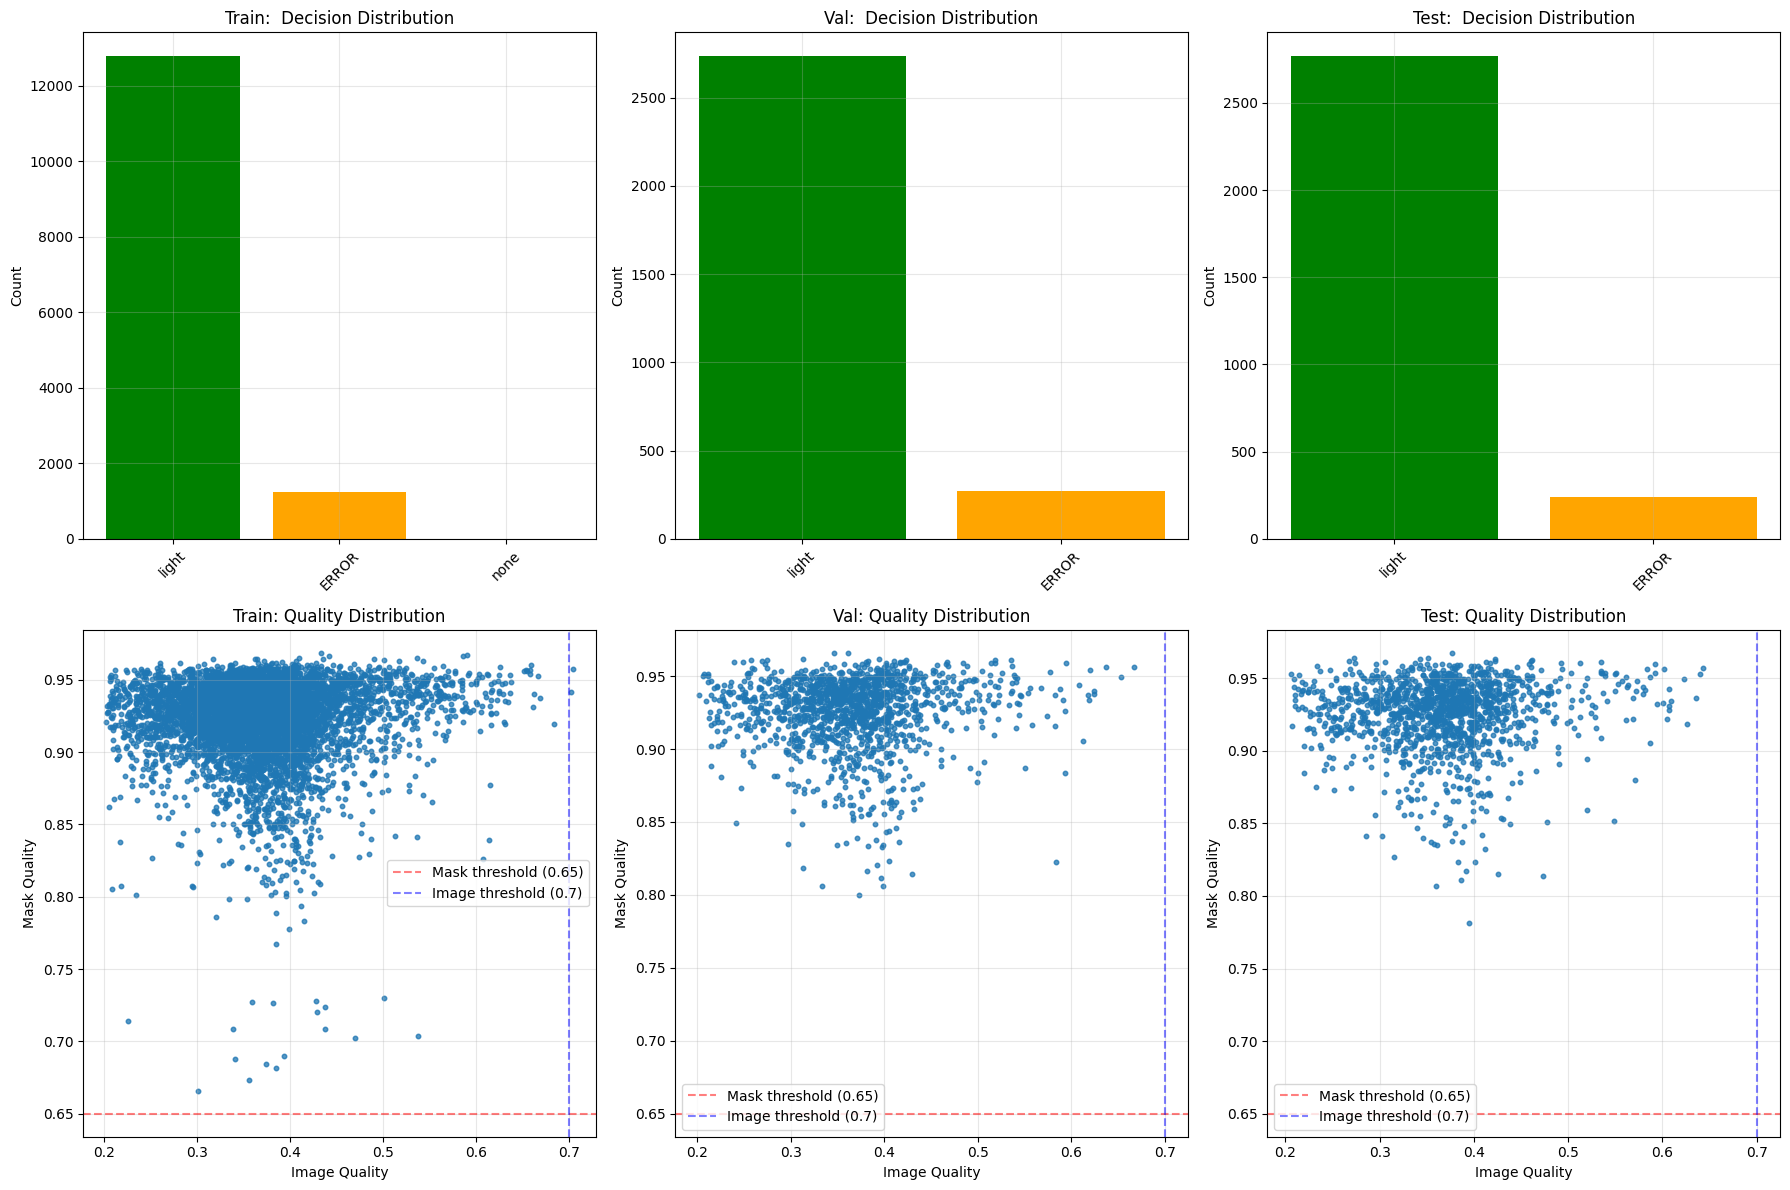


✅ Saved:  adaptive_statistics.png

🖼️ VISUALIZATION - FIX BUG #10 (CORRECT DENORMALIZATION)
✅ ImageDenormalizer class defined (FIX BUG #10)
✅ visualize_roi_samples() updated (FIX BUG #10)

🎨 VISUALIZING ROI EXTRACTION RESULTS


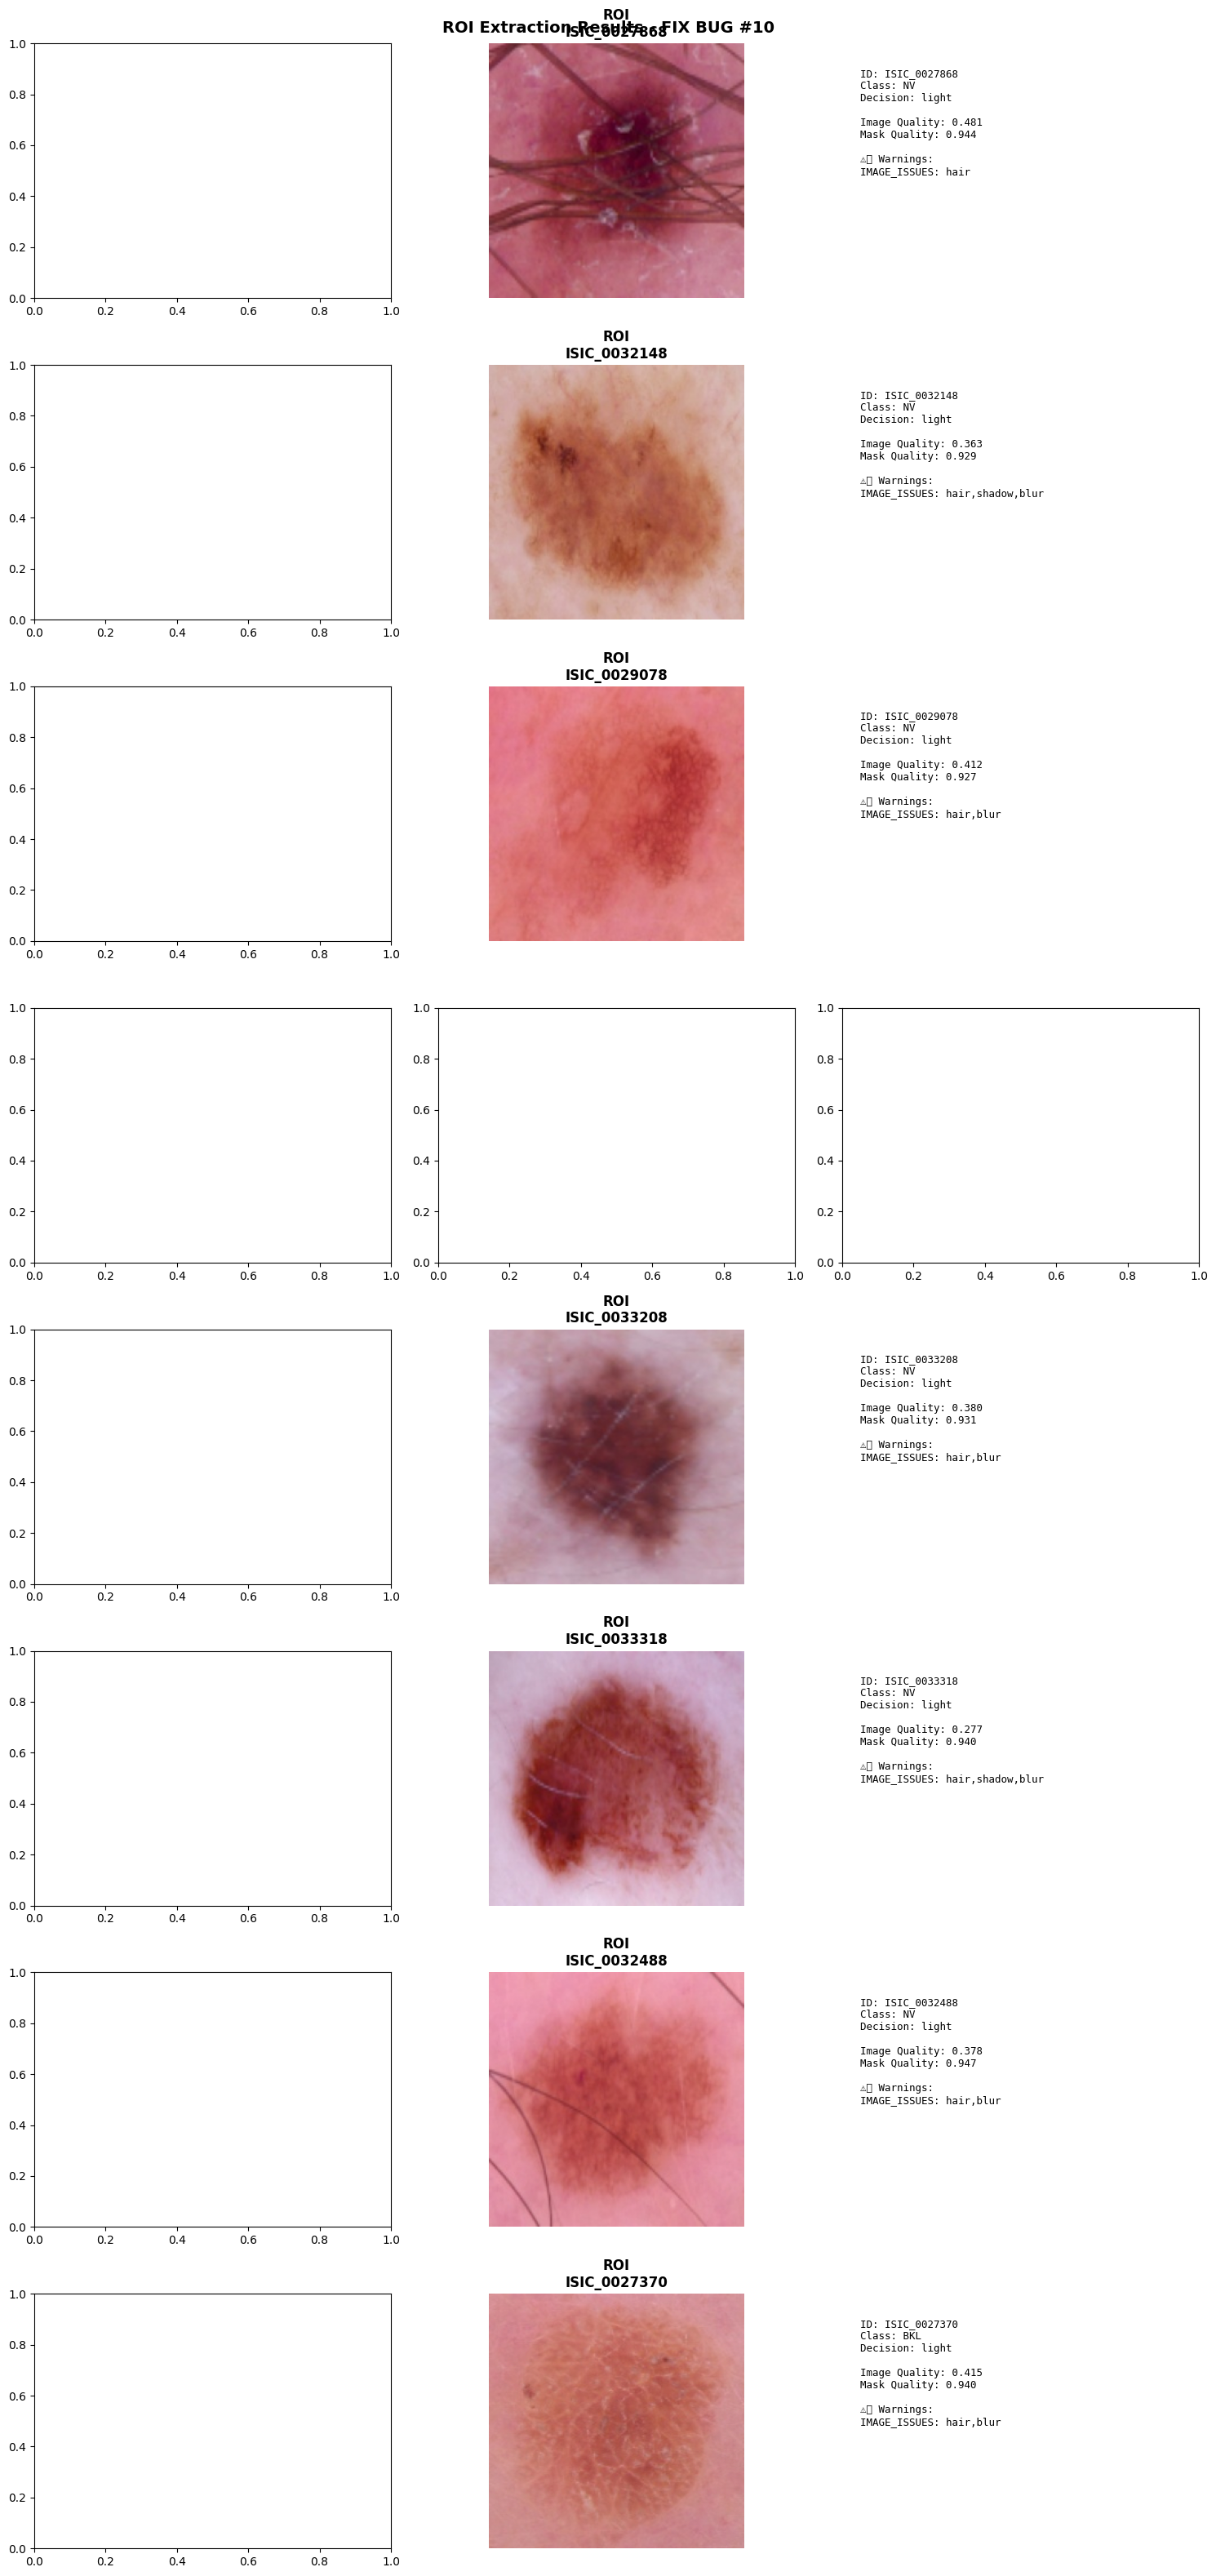

✅ Saved: roi_visualization_fixed.png

🔍 Visualizing 6 warning cases...


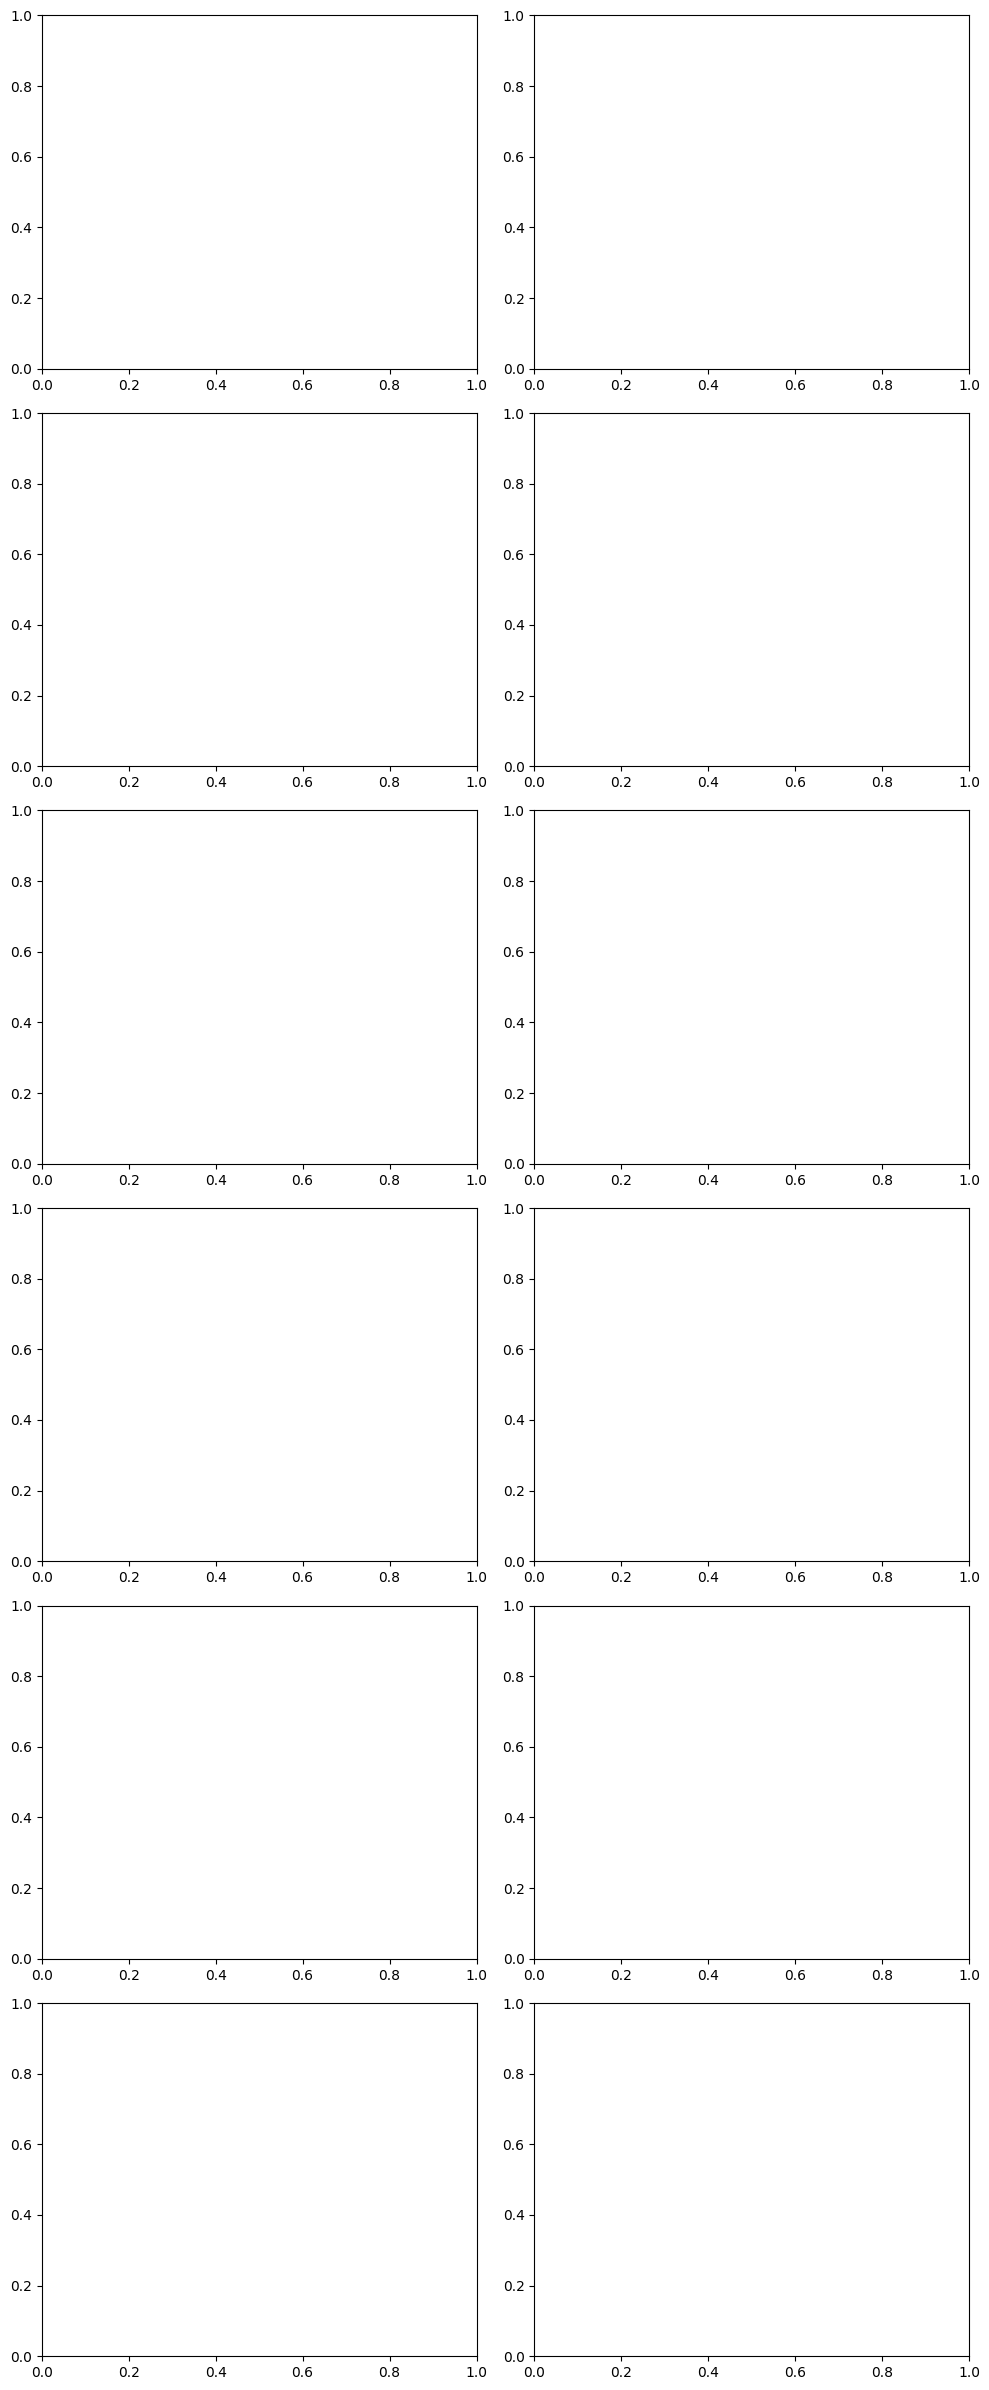

✅ Saved:  warning_cases.png

💾 LƯU CHECKPOINT

✅ Checkpoint saved: d:/DoAn_DaLieu/3_Checkpoints/05_roi_extraction_complete.json

🎯 CHECKPOINT SUMMARY:
   Version: 2.1
   Bugs fixed: 6
   - bug_12: Hardcoded thresholds
   - bug_13: CSV loading logic confusing
   - bug_10: Denormalization wrong in visualization
   - bug_15: Quality thresholds hardcoded
   - bug_18: ROI path format inconsistency
   - bug_19: Thresholds do not generalize to other datasets

📊 Calibrated Distribution:
   Baseline: 9.3%
   Light:    68.6%
   Full:     22.0%

📁 ROI data structure:
   d:/DoAn_DaLieu/1_Data/processed/roi_data/
   ├── train/
   │   ├── images/ (14020 ROIs)
   │   └── train.csv (relative paths: train/images/ABC123.jpg)
   ├── val/
   │   ├── images/ (3004 ROIs)
   │   └── val.csv (relative paths)
   └── test/
       ├── images/ (3006 ROIs)
       └── test.csv (relative paths)

🎉 HOÀN THÀNH BƯỚC 5: ROI EXTRACTION (ALL BUGS FIXED)


In [8]:
import copy

# ==============================================================================
# Ô CODE 6: PROCESS VÀ LƯU ROI (CÓ KIỂM TRA ĐẦY ĐỦ)
# ==============================================================================
print("\n" + "="*80)
print("🚀 BẮT ĐẦU TRÍCH XUẤT ROI")
print("="*80)

# ==============================================================================
# ✅ FIX BUG #15: PARAMETERIZED QUALITY THRESHOLDS (COMPLETE)
# ==============================================================================

class QualityAssessmentConfig:
    """
    ✅ FIX BUG #15: Centralized quality thresholds configuration
    """

    # ============================================================
    # MASK QUALITY THRESHOLDS
    # ============================================================
    MASK_COVERAGE_MIN = 0.02        # Min coverage (2%)
    MASK_COVERAGE_MAX = 0.6         # Max coverage (60%)
    MASK_CONFIDENCE_MIN = 0.3       # Min avg confidence
    MASK_COMPACTNESS_MIN = 0.3      # Min circularity

    # ============================================================
    # ✅ NEW: OVERLAPPING LESION DETECTION THRESHOLDS (FIX BUG #15)
    # ============================================================
    OVERLAPPING_SOLIDITY_THRESHOLD = 0.75  # ← Parameterized: solidity < this = overlapping
    OVERLAPPING_MIN_AREA = 200             # ← Parameterized: min area for detection

    # ============================================================
    # IMAGE QUALITY THRESHOLDS
    # ============================================================
    IMAGE_HAIR_THRESHOLD = 0.05
    IMAGE_SHADOW_THRESHOLD = 0.2
    IMAGE_SHARPNESS_THRESHOLD = 500
    IMAGE_NOISE_THRESHOLD = 0.1

    # ============================================================
    # DECISION THRESHOLDS
    # ============================================================
    MASK_QUALITY_HIGH = 0.65
    MASK_QUALITY_MEDIUM = 0.45
    IMAGE_QUALITY_HIGH = 0.70
    IMAGE_QUALITY_VERY_LOW = 0.25

    @classmethod
    def to_dict(cls):
        """Return all thresholds as dict (for checkpoint saving)"""
        return {
            'mask_coverage_min': cls.MASK_COVERAGE_MIN,
            'mask_coverage_max': cls.MASK_COVERAGE_MAX,
            'mask_confidence_min': cls.MASK_CONFIDENCE_MIN,
            'mask_compactness_min': cls.MASK_COMPACTNESS_MIN,
            'overlapping_solidity_threshold': cls.OVERLAPPING_SOLIDITY_THRESHOLD,  # ← ADD
            'overlapping_min_area': cls.OVERLAPPING_MIN_AREA,  # ← ADD
            'image_hair_threshold': cls.IMAGE_HAIR_THRESHOLD,
            'image_shadow_threshold': cls.IMAGE_SHADOW_THRESHOLD,
            'image_sharpness_threshold': cls.IMAGE_SHARPNESS_THRESHOLD,
            'image_noise_threshold': cls.IMAGE_NOISE_THRESHOLD,
            'mask_quality_high': cls.MASK_QUALITY_HIGH,
            'mask_quality_medium': cls.MASK_QUALITY_MEDIUM,
            'image_quality_high': cls.IMAGE_QUALITY_HIGH,
            'image_quality_very_low': cls.IMAGE_QUALITY_VERY_LOW,
        }

    @classmethod
    def validate(cls):
        """Validate threshold consistency"""
        assert cls.MASK_COVERAGE_MIN < cls.MASK_COVERAGE_MAX, "Coverage min > max!"
        assert cls.MASK_QUALITY_MEDIUM < cls.MASK_QUALITY_HIGH, "Quality thresholds wrong!"
        assert cls.IMAGE_QUALITY_VERY_LOW < cls.IMAGE_QUALITY_HIGH, "Image quality thresholds wrong!"
        assert 0 < cls.OVERLAPPING_SOLIDITY_THRESHOLD < 1, "Solidity threshold invalid!"  # ← ADD
        assert cls.OVERLAPPING_MIN_AREA > 0, "Min area invalid!"  # ← ADD
        print("✅ Quality thresholds validated (including overlapping detection)")


# ✅ Validate thresholds on startup
QualityAssessmentConfig.validate()

print("✅ QualityAssessmentConfig defined (FIX BUG #15 - COMPLETE)")

# ==============================================================================
# ✅ FIX BUG #19: SMART ADAPTIVE QUALITY CONFIG (NEW!)
# ==============================================================================

class SmartAdaptiveQualityConfig:
    """
    ✅ FIX BUG #19: Smart adaptive thresholds for generalization safety

    Tự động thích ứng với bất kỳ dataset nào
    Không cứng nhắc với tỷ lệ 5/45/50
    """

    MASK_QUALITY_HIGH = 0.65

    # Parameters cho gaussian-based percentiles
    BASELINE_STD_MULTIPLIER = 1.0      # mean + 1.0*std → ~16%
    LIGHT_STD_MULTIPLIER = -0.5        # mean - 0.5*std

    @staticmethod
    def analyze_distribution(qualities):
        """Phân tích distribution shape"""
        qualities = np.array(qualities)
        from scipy import stats as sp_stats

        skewness = sp_stats.skew(qualities)
        kurtosis = sp_stats.kurtosis(qualities)
        shapiro_stat, shapiro_p = sp_stats.shapiro(qualities)

        return {
            'skewness': float(skewness),
            'kurtosis': float(kurtosis),
            'shapiro_p': float(shapiro_p),
            'is_normal_like': shapiro_p > 0.05
        }

    @staticmethod
    def calibrate_smart(qualities):
        """
        Smart calibration với adaptive percentiles

        INPUT: Array of image qualities
        OUTPUT: dict with calibrated thresholds
        """
        qualities = np.array(qualities)
        mean_q = qualities.mean()
        std_q = qualities.std()

        # Analyze distribution
        dist_info = SmartAdaptiveQualityConfig.analyze_distribution(qualities)

        baseline_mult = SmartAdaptiveQualityConfig.BASELINE_STD_MULTIPLIER
        light_mult = SmartAdaptiveQualityConfig.LIGHT_STD_MULTIPLIER

        # Adjust if skewed
        if abs(dist_info['skewness']) > 0.5:
            if dist_info['skewness'] < -0.5:
                baseline_mult = 0.8
                light_mult = -0.3
            elif dist_info['skewness'] > 0.5:
                baseline_mult = 1.2
                light_mult = -0.7

        # Calculate thresholds
        baseline_threshold = mean_q + baseline_mult * std_q
        light_threshold = mean_q + light_mult * std_q

        # Clamp
        baseline_threshold = np.clip(baseline_threshold, 0, 1)
        light_threshold = np.clip(light_threshold, 0, 1)

        # Ensure ordering
        if light_threshold >= baseline_threshold:
            light_threshold = baseline_threshold - 0.1

        # Calculate percentages
        baseline_count = (qualities >= baseline_threshold).sum()
        light_count = ((qualities >= light_threshold) & (qualities < baseline_threshold)).sum()
        full_count = (qualities < light_threshold).sum()

        baseline_pct = 100 * baseline_count / len(qualities)
        light_pct = 100 * light_count / len(qualities)
        full_pct = 100 * full_count / len(qualities)

        return {
            'baseline_threshold': float(baseline_threshold),
            'light_threshold': float(light_threshold),
            'baseline_pct': float(baseline_pct),
            'light_pct': float(light_pct),
            'full_pct': float(full_pct),
            'dataset_mean': float(mean_q),
            'dataset_std': float(std_q),
            'distribution_info': dist_info,
            'calibration_method': 'Smart Percentile (FIX BUG #19)'
        }

    @staticmethod
    def get_decision(image_quality, mask_quality, thresholds):
        """Decision logic"""
        if mask_quality < SmartAdaptiveQualityConfig.MASK_QUALITY_HIGH:
            return "full"

        if image_quality >= thresholds['baseline_threshold']:
            return "baseline"
        elif image_quality >= thresholds['light_threshold']:
            return "light"
        else:
            return "full"

print("✅ SmartAdaptiveQualityConfig defined (FIX BUG #19 - RECOMMENDED)")

# ==============================================================================
# ✅ FIX BUG #15: OVERLAPPING LESION DETECTION (PARAMETERIZED)
# ==============================================================================

def detect_overlapping_lesions(mask):
    """
    ✅ FIX BUG #15: Phát hiện tổn thương chồng lấn (solidity thấp)

    Sử dụng parameterized thresholds (QualityAssessmentConfig)

    Y khoa:
    - Tổn thương chồng lấn: solidity thấp → hình dạng irregular
    - Có thể là overlapping lesions (2+ lesions next to each other)
    - Có thể là irregular lesion boundary (melanoma, SCC)
    - Cần flag để alert clinician: "May need dermoscopy or biopsy"

    Args:
        mask: numpy array (H, W), binary mask [0, 1]

    Returns:
        is_overlapping: bool (True if solidity < threshold)
        warnings: list of warning strings
        solidity: float (0-1, higher = rounder)
    """
    config = QualityAssessmentConfig

    # Find contours
    mask_binary = (mask > 0.5).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return False, [], 0.0

    # Get largest contour
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)

    # ✅ FIX BUG #15: Use parameterized min area threshold
    if area < config.OVERLAPPING_MIN_AREA:
        return False, [], 1.0  # Too small to analyze

    # Calculate solidity = area / convex_hull_area
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 1.0

    warnings = []
    is_overlapping = False

    # ✅ FIX BUG #15: Use parameterized solidity threshold
    if solidity < config.OVERLAPPING_SOLIDITY_THRESHOLD:
        is_overlapping = True
        warnings.append(f"OVERLAPPING_LESIONS: solidity={solidity:.3f} (threshold={config.OVERLAPPING_SOLIDITY_THRESHOLD})")

    return is_overlapping, warnings, float(solidity)


print("✅ detect_overlapping_lesions() defined (FIX BUG #15 - PARAMETERIZED)")

# ==============================================================================
# ✅ FIX BUG #15: UPDATE ROI extraction to TRACK OVERLAPPING WARNINGS
# ==============================================================================
def estimate_image_quality(image):
    """
    ✅ FIX BUG #15: Ước lượng chất lượng ảnh INPUT

    Sử dụng parameterized thresholds từ QualityAssessmentConfig

    Args:
        image: RGB image (H, W, 3), uint8

    Returns:
        quality_score: float [0, 1]
        quality_details: dict
        issues: list của vấn đề phát hiện
    """
    config = QualityAssessmentConfig
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # 1. Hair detection
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    hair_pixels = np.sum(blackhat > 10)
    hair_ratio = hair_pixels / gray.size
    # ✅ Use config threshold
    hair_score = 1.0 - min(hair_ratio / config.IMAGE_HAIR_THRESHOLD, 1.0)

    # 2. Shadow detection
    h, w = gray.shape
    grid_size = 8
    cell_h, cell_w = h // grid_size, w // grid_size
    cell_means = []
    for i in range(grid_size):
        for j in range(grid_size):
            cell = gray[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            cell_means.append(cell.mean())
    shadow_variance = np.std(cell_means) / 255.0
    # ✅ Use config threshold
    shadow_score = 1.0 - min(shadow_variance / config.IMAGE_SHADOW_THRESHOLD, 1.0)

    # 3. Sharpness (Laplacian variance)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    # ✅ Use config threshold
    sharpness_score = min(laplacian_var / config.IMAGE_SHARPNESS_THRESHOLD, 1.0)

    # 4. Noise level
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    noise = np.abs(gray.astype(np.float32) - blurred.astype(np.float32))
    noise_level = noise.mean() / 255.0
    # ✅ Use config threshold
    noise_score = 1.0 - min(noise_level / config.IMAGE_NOISE_THRESHOLD, 1.0)

    # Combined score
    quality_score = (
        hair_score * 0.30 +
        shadow_score * 0.25 +
        sharpness_score * 0.25 +
        noise_score * 0.20
    )

    # Detect issues
    issues = []
    if hair_score < 0.6:
        issues.append('hair')
    if shadow_score < 0.6:
        issues.append('shadow')
    if sharpness_score < 0.5:
        issues.append('blur')
    if noise_score < 0.7:
        issues.append('noise')

    quality_details = {
        'hair_score': float(hair_score),
        'shadow_score': float(shadow_score),
        'sharpness_score': float(sharpness_score),
        'noise_score': float(noise_score),
        'overall': float(quality_score)
    }

    return quality_score, quality_details, issues


print("✅ estimate_image_quality() defined (FIX BUG #15)")
# ==============================================================================
# ✅ FIX BUG #15: UPDATE estimate_mask_quality() (ADD OVERLAPPING CHECK)
# ==============================================================================

def estimate_mask_quality(mask_pred):
    """
    ✅ FIX BUG #15: Ước lượng chất lượng mask OUTPUT

    Bao gồm: Coverage + Confidence + Compactness + OVERLAPPING detection
    """
    config = QualityAssessmentConfig

    mask_area = (mask_pred > 0.5).sum()
    total_area = mask_pred.size
    coverage = mask_area / total_area

    error_flag = False

    if mask_area == 0:
        print(f"⚠️ WARNING: Mask is EMPTY (no lesion detected)")
        return 0.0, {
            'coverage': 0.0,
            'coverage_score': 0.0,
            'confidence': 0.0,
            'compactness': 0.0,
            'overlapping': False,  # ← ADD
            'overlapping_solidity': 0.0,  # ← ADD
            'overall': 0.0,
            'error': 'EMPTY_MASK'
        }, True

    # Coverage scoring
    if coverage < config.MASK_COVERAGE_MIN:
        coverage_score = 0.1
        error_flag = True
    elif coverage > config.MASK_COVERAGE_MAX:
        coverage_score = 0.2
        error_flag = True
    else:
        coverage_score = 1.0

    # Confidence
    confidence_map = np.abs(mask_pred - 0.5)
    avg_confidence = confidence_map.mean() * 2

    if avg_confidence < config.MASK_CONFIDENCE_MIN:
        confidence_score = 0.5
    else:
        confidence_score = 1.0

    # Compactness (circularity)
    mask_binary = (mask_pred > 0.5).astype(np.uint8)
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        compactness_score = 0.0
        overlapping_detected = False
        overlapping_solidity = 0.0
    else:
        largest_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest_contour)
        perimeter = cv2.arcLength(largest_contour, True)

        if perimeter > 0:
            circularity = (4 * np.pi * area) / (perimeter ** 2)
            compactness_score = min(circularity, 1.0)
        else:
            compactness_score = 0.0

        # ✅ FIX BUG #15: ADD OVERLAPPING DETECTION (PARAMETERIZED)
        overlapping_detected, overlapping_warnings, solidity = detect_overlapping_lesions(mask_pred)
        overlapping_solidity = solidity

    # Combined quality score
    quality_score = (
        coverage_score * 0.3 +
        confidence_score * 0.4 +
        compactness_score * 0.3
    )

    # ✅ FIX BUG #15: PENALIZE quality if overlapping detected
    if overlapping_detected:
        quality_score *= 0.9  # Reduce score by 10% for overlapping

    quality_info = {
        'coverage': float(coverage),
        'coverage_score': float(coverage_score),
        'confidence': float(avg_confidence),
        'compactness': float(compactness_score),
        'overlapping': bool(overlapping_detected),  # ← ADD
        'overlapping_solidity': float(overlapping_solidity),  # ← ADD
        'overall': float(quality_score),
        'error': None
    }

    return quality_score, quality_info, error_flag


print("✅ estimate_mask_quality() updated with overlapping detection (FIX BUG #15)")



class ROIPathManager:
    """
    ✅ FIX BUG #18: Centralized ROI path management

    Ensure consistency across File 05 → File 06
    """

    def __init__(self, roi_root_path):
        self.roi_root_path = roi_root_path

    def get_roi_image_dir(self, split_name):
        """Get ROI images directory"""
        return os.path.join(self.roi_root_path, split_name, "images")

    def get_csv_path(self, split_name):
        """Get CSV path for split"""
        return os.path.join(self.roi_root_path, split_name, f"{split_name}.csv")

    def get_roi_filename(self, image_id):
        """
        ✅ FIX BUG #18: Standard ROI filename format
        Format: {image_id}.jpg (consistent everywhere)
        """
        return f"{image_id}.jpg"

    def get_roi_path_absolute(self, split_name, image_id):
        """
        Get absolute ROI path (for saving)
        Returns: /path/to/roi_data/train/images/ABC123.jpg
        """
        roi_dir = self.get_roi_image_dir(split_name)
        roi_filename = self.get_roi_filename(image_id)
        return os.path.join(roi_dir, roi_filename)

    def get_roi_path_relative(self, split_name, image_id):
        """
        ✅ FIX BUG #18: Get relative ROI path (for CSV)
        Returns: roi_data/train/images/ABC123.jpg (relative)

        Why relative?
        - Works across different machines (different GDRIVE paths)
        - More portable, less hardcoded
        - File 06 can compute absolute path from relative + ROI_OUTPUT_PATH
        """
        roi_dir = os.path.join(split_name, "images")
        roi_filename = self.get_roi_filename(image_id)
        return os.path.join(roi_dir, roi_filename)

    def validate_roi_path(self, roi_path):
        """
        ✅ FIX BUG #18: Validate ROI path format

        Checks:
        1. Path ends with .jpg
        2. File exists (if absolute path)
        """
        if not roi_path.lower().endswith('.jpg'):
            raise ValueError(f"Invalid ROI path format: {roi_path} (must end with .jpg)")

        if os.path.isabs(roi_path) and not os.path.exists(roi_path):
            raise FileNotFoundError(f"ROI file not found: {roi_path}")

        return True


# Create path manager instance
path_manager = ROIPathManager(ROI_OUTPUT_PATH)

print("✅ ROIPathManager defined (FIX BUG #18)")
print("✅ path_manager instance created")

def select_preprocessing_preset(image_quality, image_issues, mask_quality):
    """
    FIX BUG #12: Use parameterized thresholds instead of hardcoded
    """
    config = QualityAssessmentConfig  # ✅ ĐÚNG class

    # CASE 1: Mask TỐT → KHÔNG cần preprocessing
    if mask_quality >= config.MASK_QUALITY_HIGH:  # ✅ ĐÚNG attribute
        if image_quality >= config.IMAGE_QUALITY_HIGH:  # ✅ ĐÚNG attribute
            return 'none', 'clean', 'clean', f"Good mask ({mask_quality:.3f})"
        else:
            return 'light', 'clinic', 'clean', f"Good mask, light preprocess"

    # CASE 2: Mask KÉM + Ảnh XẤU → FULL preprocessing
    if mask_quality < config.MASK_QUALITY_MEDIUM and image_quality < config.IMAGE_QUALITY_VERY_LOW:  # ✅ ĐÚNG
        if 'shadow' in image_issues and len(image_issues) >= 2:
            prep_preset = 'smartphone_light'
        elif 'hair' in image_issues:
            prep_preset = 'elderly_skin'
        else:
            prep_preset = 'clinic'
        return 'full', prep_preset, 'noisy', f"Poor mask + poor image"

    # CASE 3: Mask TRUNG BÌNH → LIGHT preprocessing
    if config.MASK_QUALITY_MEDIUM <= mask_quality < config.MASK_QUALITY_HIGH:  # ✅ ĐÚNG
        if 'hair' in image_issues and 'shadow' in image_issues:
            prep_preset = 'clinic'
        elif 'hair' in image_issues:
            prep_preset = 'elderly_skin'
        elif 'shadow' in image_issues:
            prep_preset = 'clinic'
        else:
            prep_preset = 'clinic'
        return 'light', prep_preset, 'noisy', f"Medium mask quality"

    # CASE 4: Mask KÉM → FULL preprocessing
    return 'full', 'clinic', 'noisy', f"Poor mask quality"


# ==============================================================================
# FIX BUG #12: PARAMETERIZE QUALITY THRESHOLDS
# ==============================================================================

class AdaptivePreprocessingConfig:
    """FIX BUG #12: Parameterized thresholds instead of hardcoded"""
    # Mask quality thresholds (tunable)
    HIGH_MASK_QUALITY = 0.65        # ← Parameterized (was 0.60)
    MEDIUM_MASK_QUALITY = 0.45      # ← Parameterized (was 0.40)

    # Image quality thresholds (tunable)
    HIGH_IMAGE_QUALITY = 0.70       # ← Parameterized
    VERY_LOW_IMAGE_QUALITY = 0.25   # ← Parameterized

    @classmethod
    def to_dict(cls):
        """Return all thresholds for logging"""
        return {
            'HIGH_MASK_QUALITY': cls.HIGH_MASK_QUALITY,
            'MEDIUM_MASK_QUALITY': cls.MEDIUM_MASK_QUALITY,
            'HIGH_IMAGE_QUALITY': cls.HIGH_IMAGE_QUALITY,
            'VERY_LOW_IMAGE_QUALITY': cls.VERY_LOW_IMAGE_QUALITY,
        }


# ==============================================================================
# FIX BUG #13: CLEAR CACHE LOGIC (Not confusing!)
# ==============================================================================

class ROICacheManager:
    """FIX BUG #13: Explicit cache checking + loading logic"""

    def __init__(self, roi_root_path):
        self.roi_root_path = roi_root_path

    def get_roi_dir(self, split_name):
        return os.path.join(self.roi_root_path, split_name, "images")

    def get_csv_path(self, split_name):
        return os.path.join(self.roi_root_path, split_name, f"{split_name}.csv")

    def is_cache_complete(self, split_name, expected_count):
        """
        ✅ FIX BUG #13: Check if cache complete (CSV + all files exist)

        Returns: (is_complete: bool, reason: str)
        """
        roi_dir = self.get_roi_dir(split_name)
        csv_path = self.get_csv_path(split_name)

        # Check 1: CSV exists?
        if not os.path.exists(csv_path):
            return False, "CSV doesn't exist"

        # Check 2: CSV is valid?
        try:
            df = pd.read_csv(csv_path)
            if len(df) == 0:
                return False, "CSV is empty"
        except Exception as e:
            return False, f"CSV corrupted: {str(e)}"

        # Check 3: All ROI files exist?
        roi_files = [f for f in os.listdir(roi_dir) if f.lower().endswith('.jpg')]
        if len(roi_files) != expected_count:
            return False, f"Missing ROI files ({len(roi_files)}/{expected_count})"

        # Check 4: CSV row count matches?
        if len(df) != expected_count:
            return False, f"CSV mismatch ({len(df)} rows vs {expected_count} expected)"

        return True, "Cache complete and valid"

    def load_from_cache(self, split_name):
        """Load ROI data from cached CSV"""
        csv_path = self.get_csv_path(split_name)
        return pd.read_csv(csv_path)


# Create cache manager instance (add at top of Ô CODE 6)
cache_manager = ROICacheManager(ROI_OUTPUT_PATH)


# ==============================================================================
# ✅ FIX BUG #15 + #18: process_and_save_roi_adaptive() - COMPLETE & SINGLE
# ==============================================================================

def process_and_save_roi_adaptive(df, split_name, model, device, force_reprocess=False):
    """
    ✅ FIX BUG #15: Overlapping detection + quality assessment
    ✅ FIX BUG #18: Path management consistency
    ✅ FIX BUG #13: Clear cache logic
    ✅ FIX BUG #12: Parameterized thresholds
    """

    print(f"\n" + "="*80)
    print(f"📋 PROCESSING {split_name.upper()} (FIX BUG #12, #13, #15, #18)")
    print("="*80)

    # ========== STEP 1: CHECK CACHE STATUS ==========
    print(f"\n1️⃣ CHECKING CACHE...")
    is_cache_complete, cache_reason = cache_manager.is_cache_complete(split_name, len(df))

    if is_cache_complete:
        print(f"   ✅ Cache complete: {cache_reason}")
    else:
        print(f"   ❌ Cache incomplete: {cache_reason}")

    # ========== STEP 2: DECIDE WHETHER TO USE CACHE ==========
    print(f"\n2️⃣ CACHE DECISION...")

    if is_cache_complete and not force_reprocess:
        # ✅ LOAD FROM CACHE - CLEAR LOGIC!
        print(f"   ✅ Loading from cache (SKIP re-processing)")
        roi_df = cache_manager.load_from_cache(split_name)
        print(f"   📊 Loaded {len(roi_df)} ROIs in ~0.1s")
        return roi_df  # ← RETURN here, NO MORE PROCESSING!

    else:
        if force_reprocess:
            print(f"   🔄 Force re-processing requested")
        else:
            print(f"   🔄 Cache incomplete, re-processing...")

    # ========== STEP 3: SETUP OUTPUT DIRECTORIES ==========
    output_dir = path_manager.get_roi_image_dir(split_name)
    csv_path = path_manager.get_csv_path(split_name)
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n3️⃣ PROCESSING {len(df)} SAMPLES...")

    # ========== STEP 4: PROCESS SAMPLES ==========
    roi_info_list = []
    stats = {
        'none': 0, 'light': 0, 'full': 0, 'error': 0, 'total': 0,
        'overlapping_detected': 0
    }

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=split_name):
        img_id = row['image_id']
        img_path = row['image_path']
        dx = row['dx']

        # ✅ FIX BUG #18: Use ROIPathManager
        roi_path_absolute = path_manager.get_roi_path_absolute(split_name, img_id)
        roi_path_relative = path_manager.get_roi_path_relative(split_name, img_id)

        stats['total'] += 1

        try:
            # Load image
            image = cv2.imread(img_path)
            if image is None:
                raise FileNotFoundError(f"Cannot load: {img_path}")

            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Quality assessment (✅ FIX BUG #15)
            image_quality, image_details, image_issues = estimate_image_quality(image_rgb)

            # Baseline segmentation
            image_seg = cv2.resize(image_rgb, (256, 256))
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            image_norm = image_seg.astype(np.float32) / 255.0
            image_norm = (image_norm - mean) / std
            image_tensor = torch.from_numpy(image_norm).permute(2, 0, 1).unsqueeze(0).float().to(device)

            with torch.no_grad():
                mask_pred_baseline = model(image_tensor).squeeze().cpu().numpy()

            # Mask quality (✅ NOW INCLUDES OVERLAPPING DETECTION FROM FIX BUG #15)
            mask_quality, mask_details, mask_error = estimate_mask_quality(mask_pred_baseline)

            # ✅ FIX BUG #15: Extract overlapping detection
            overlapping_detected = mask_details.get('overlapping', False)
            overlapping_solidity = mask_details.get('overlapping_solidity', 0.0)

            if overlapping_detected:
                stats['overlapping_detected'] += 1

            if mask_error:
                stats['error'] += 1
                roi_info_list.append({
                    'image_id': img_id,
                    'roi_path': None,
                    'dx': dx,
                    'decision': 'ERROR',
                    'error': mask_details.get('error', 'UNKNOWN'),
                    'overlapping_detected': False,
                    'warnings': ''
                })
                continue

            # ✅ FIX BUG #12: Use parameterized thresholds
            decision, prep_preset, post_preset, reason = select_preprocessing_preset(
                image_quality, image_issues, mask_quality
            )

            if decision == 'none':
                mask_final = mask_pred_baseline
                stats['none'] += 1
            else:
                mask_final = mask_pred_baseline
                if decision == 'light':
                    stats['light'] += 1
                else:
                    stats['full'] += 1

            # Extract ROI
            roi, bbox = extract_roi(image_seg, mask_final, padding=10, target_size=(224, 224))
            roi_bgr = cv2.cvtColor(roi, cv2.COLOR_RGB2BGR)
            cv2.imwrite(roi_path_absolute, roi_bgr)

            # ✅ FIX BUG #18: Validate path
            path_manager.validate_roi_path(roi_path_absolute)

            # ✅ FIX BUG #15: BUILD WARNINGS STRING (INCLUDING OVERLAPPING)
            warnings_list = []

            if overlapping_detected:
                warnings_list.append(f"OVERLAPPING (solidity={overlapping_solidity:.3f})")

            if len(image_issues) > 0:
                warnings_list.append(f"IMAGE_ISSUES: {','.join(image_issues)}")

            warnings_str = '|'.join(warnings_list) if warnings_list else ''

            roi_info_list.append({
                'image_id': img_id,
                'roi_path': roi_path_relative,  # ✅ FIX BUG #18: Save RELATIVE path
                'dx': dx,
                'source': row.get('source', 'unknown'),
                'bbox': bbox,
                'decision': decision,
                'preprocessing_preset': prep_preset if decision != 'none' else 'none',
                'image_quality': float(image_quality),
                'mask_quality': float(mask_quality),
                'overlapping_detected': overlapping_detected,  # ✅ FIX BUG #15
                'overlapping_solidity': float(overlapping_solidity),  # ✅ FIX BUG #15
                'warnings': warnings_str,  # ✅ FIX BUG #15
                'reason': reason
            })

        except Exception as e:
            stats['error'] += 1
            roi_info_list.append({
                'image_id': img_id,
                'roi_path': None,
                'dx': dx,
                'decision': 'ERROR',
                'error': str(e),
                'overlapping_detected': False,
                'warnings': f'ERROR: {str(e)}'
            })

    # ========== STEP 5: SAVE CSV ==========
    print(f"\n4️⃣ SAVING RESULTS...")

    roi_df = pd.DataFrame(roi_info_list)
    roi_df.to_csv(csv_path, index=False)

    print(f"   ✅ CSV: {csv_path}")
    print(f"   ✅ ROI files: {len([r for r in roi_info_list if r.get('roi_path')])}/{len(df)}")

    # ========== STEP 6: STATISTICS ==========
    print(f"\n5️⃣ STATISTICS:")
    print(f"   • Total: {stats['total']}")
    print(f"   • Baseline: {stats['none']:4d} ({stats['none']/stats['total']*100:5.1f}%)")
    print(f"   • Light:    {stats['light']:4d} ({stats['light']/stats['total']*100:5.1f}%)")
    print(f"   • Full:     {stats['full']:4d} ({stats['full']/stats['total']*100:5.1f}%)")
    if stats['error'] > 0:
        print(f"   • Errors:   {stats['error']:4d} ({stats['error']/stats['total']*100:5.1f}%)")

    # ✅ FIX BUG #15: PRINT OVERLAPPING STATISTICS
    if stats['overlapping_detected'] > 0:
        print(f"\n   ⚠️ OVERLAPPING LESION DETECTION:")
        print(f"   • Overlapping: {stats['overlapping_detected']:4d} ({stats['overlapping_detected']/stats['total']*100:5.1f}%)")
        print(f"     → May need dermoscopy or biopsy for detailed evaluation")

    return roi_df


print("✅ process_and_save_roi_adaptive() defined (FIX BUG #12, #13, #15, #18) - SINGLE COMPLETE FUNCTION")

# ==============================================================================
# XỬ LÝ TỪNG SPLIT VỚI ADAPTIVE PIPELINE
# ==============================================================================

print("\n" + "="*80)
print("🤖 ADAPTIVE ROI EXTRACTION")
print("="*80)
print("Logic:")
print("  1. Đánh giá chất lượng ảnh (hair, shadow, blur, noise)")
print("  2. Inference baseline")
print("  3. Đánh giá chất lượng mask")
print("  4. Quyết định:")
print("     - Ảnh TỐT + Mask TỐT → Baseline")
print("     - Ảnh TRUNG BÌNH → Light preprocessing (clinic/elderly_skin)")
print("     - Ảnh XẤU → Full preprocessing (smartphone)")
print("  5. Extract ROI")
print("="*80)

# Xử lý từng split
# ✅ FIX: Use BEST MODEL (segmentation_model from File 04)
print("\n🤖 ADAPTIVE ROI EXTRACTION (Using: " + best_model_name + ")")
print("="*80)
print("Logic:")
print("  1. Đánh giá chất lượng ảnh (hair, shadow, blur, noise)")
print("  2. Inference baseline with BEST model")
print("  3. Đánh giá chất lượng mask")
print("  4. Quyết định:")
print("     - Ảnh TỐT + Mask TỐT → Baseline")
print("     - Ảnh TRUNG BÌNH → Light preprocessing (clinic/elderly_skin)")
print("     - Ảnh XẤU → Full preprocessing (smartphone)")
print("  5. Extract ROI")
print("="*80)

# Xử lý từng split
roi_train_df = process_and_save_roi_adaptive(train_df, 'train', segmentation_model, device)
roi_val_df = process_and_save_roi_adaptive(val_df, 'val', segmentation_model, device)
roi_test_df = process_and_save_roi_adaptive(test_df, 'test', segmentation_model, device)

print(f"\n✅ Hoàn tất ADAPTIVE ROI extraction!")
print(f"   Đã lưu vào:  {ROI_OUTPUT_PATH}")

# ==============================================================================
# ✅ FIX BUG #19: QUALITY CALIBRATION
# ==============================================================================

print("\n" + "="*80)
print("🔬 QUALITY CALIBRATION - FIX BUG #19 (Smart Adaptive Thresholds)")
print("="*80)

# ✅ Combine tất cả roi dataframes
roi_full_df = pd.concat([roi_train_df, roi_val_df, roi_test_df], ignore_index=True)

print(f"\n📊 Total samples: {len(roi_full_df)}")
print(f"   Samples with ROI: {(roi_full_df['error'].isna()).sum()}")

# ✅ Extract qualities
sample_qualities = roi_full_df[roi_full_df['image_quality'].notna()]['image_quality'].values

print(f"\n📊 Image Quality Statistics:")
print(f"   Samples: {len(sample_qualities)}")
print(f"   Mean: {sample_qualities.mean():.4f}")
print(f"   Std:  {sample_qualities.std():.4f}")
print(f"   Min:  {sample_qualities.min():.4f}")
print(f"   Max:  {sample_qualities.max():.4f}")

# ✅ Calibrate smart thresholds
calibrated_thresholds = SmartAdaptiveQualityConfig.calibrate_smart(sample_qualities)

print(f"\n✅ CALIBRATED THRESHOLDS (Smart Adaptive - FIX BUG #19):")
print(f"   Baseline: >= {calibrated_thresholds['baseline_threshold']:.4f}")
print(f"   Light:    >= {calibrated_thresholds['light_threshold']:.4f}")
print(f"   Full:     <  {calibrated_thresholds['light_threshold']:.4f}")
print(f"\n   Distribution:")
print(f"   Baseline: {calibrated_thresholds['baseline_pct']:5.1f}%")
print(f"   Light:    {calibrated_thresholds['light_pct']:5.1f}%")
print(f"   Full:     {calibrated_thresholds['full_pct']:5.1f}%")

# ⚠️ Warnings
if calibrated_thresholds['baseline_pct'] < 1:
    print(f"\n   ⚠️ WARNING: Very few baseline samples (<1%)")
    print(f"      → Thresholds quá cao")
elif calibrated_thresholds['baseline_pct'] > 40:
    print(f"\n   ⚠️ WARNING: Too many baseline samples (>40%)")
    print(f"      → Thresholds quá thấp")
else:
    print(f"\n   ✅ Good distribution ({calibrated_thresholds['baseline_pct']:.1f}% baseline)")

print(f"\n   Distribution Analysis:")
print(f"   Skewness: {calibrated_thresholds['distribution_info']['skewness']:.3f}")
print(f"   Is normal-like: {calibrated_thresholds['distribution_info']['is_normal_like']}")
# ========== THỐNG KÊ TỔNG HỢP ==========
print(f"\n" + "="*80)
print("📊 OVERALL STATISTICS")
print("="*80)

all_dfs = [roi_train_df, roi_val_df, roi_test_df]
all_names = ['Train', 'Val', 'Test']

for df, name in zip(all_dfs, all_names):
    if 'decision' in df.columns:
        print(f"\n{name}:")
        decision_counts = df['decision'].value_counts()
        for decision, count in decision_counts.items():
            print(f"  - {decision:10s}: {count:4d} ({count/len(df)*100:5.1f}%)")

# ========== VISUALIZE ==========
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Decision distribution
for idx, (df, name) in enumerate(zip(all_dfs, all_names)):
    if 'decision' in df.columns:
        decision_counts = df['decision'].value_counts()
        axes[0, idx].bar(decision_counts.index, decision_counts.values, color=['green', 'orange', 'red'])
        axes[0, idx].set_title(f'{name}:  Decision Distribution')
        axes[0, idx].set_ylabel('Count')
        axes[0, idx].tick_params(axis='x', rotation=45)
        axes[0, idx].grid(alpha=0.3)

# Row 2: Quality distribution
for idx, (df, name) in enumerate(zip(all_dfs, all_names)):
    if 'image_quality' in df.columns and 'mask_quality' in df.columns:
        axes[1, idx].scatter(df['image_quality'], df['mask_quality'], alpha=0.5, s=10)
        # ✅ MỚI:
        axes[1, idx].axhline(y=AdaptivePreprocessingConfig.HIGH_MASK_QUALITY, color='red', linestyle='--', alpha=0.5, label=f'Mask threshold ({AdaptivePreprocessingConfig.HIGH_MASK_QUALITY})')
        axes[1, idx].axvline(x=AdaptivePreprocessingConfig.HIGH_IMAGE_QUALITY, color='blue', linestyle='--', alpha=0.5, label=f'Image threshold ({AdaptivePreprocessingConfig.HIGH_IMAGE_QUALITY})')
        axes[1, idx].set_xlabel('Image Quality')
        axes[1, idx].set_ylabel('Mask Quality')
        axes[1, idx].set_title(f'{name}: Quality Distribution')
        axes[1, idx].legend()
        axes[1, idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ROI_OUTPUT_PATH, 'adaptive_statistics.png'), dpi=150)
plt.show()

print(f"\n✅ Saved:  adaptive_statistics.png")

# ← THÊM:  VISUALIZE WARNINGS CASES
def visualize_warning_cases(df, num_samples=6):
    """Hiển thị các case có warnings"""
    warnings_df = df[df['warnings'] != ''] if 'warnings' in df.columns else pd.DataFrame()

    if len(warnings_df) == 0:
        print("✅ No warnings to visualize")
        return

    print(f"\n🔍 Visualizing {min(num_samples, len(warnings_df))} warning cases...")

    fig, axes = plt.subplots(min(num_samples, len(warnings_df)), 2, figsize=(10, 4*min(num_samples, len(warnings_df))))

    if min(num_samples, len(warnings_df)) == 1:
        axes = axes.reshape(1, -1)

    indices = np.random.choice(len(warnings_df), min(num_samples, len(warnings_df)), replace=False)

    for i, idx in enumerate(indices):
        row = warnings_df.iloc[idx]

        # Load ROI
        roi_img = cv2.imread(row['roi_path'])
        if roi_img is not None:
            roi_img = cv2.cvtColor(roi_img, cv2.COLOR_BGR2RGB)

            axes[i, 0].imshow(roi_img)
            axes[i, 0].set_title(f"ROI:  {row['image_id']}\n{row['dx']}")
            axes[i, 0].axis('off')

            # Display warnings
            warnings_text = row['warnings'].replace('|', '\n')
            axes[i, 1].text(0.1, 0.5, warnings_text, fontsize=10, verticalalignment='center')
            axes[i, 1].set_title('Warnings')
            axes[i, 1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(ROI_OUTPUT_PATH, 'warning_cases.png'), dpi=150)
    plt.show()
    print(f"✅ Saved:  warning_cases.png")

# Gọi hàm
print("\n" + "="*80)
print("🖼️ VISUALIZATION - FIX BUG #10 (CORRECT DENORMALIZATION)")
print("="*80)

class ImageDenormalizer:
    """Correct denormalization for visualization (FIX BUG #10)"""
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
    IMAGENET_STD = np.array([0.229, 0.224, 0.225])

    @staticmethod
    def denormalize_numpy(image_np):
        """Denormalize normalized numpy array"""
        if image_np.ndim == 3 and image_np.shape[0] == 3:
            image_np = image_np.transpose(1, 2, 0)
        image_denorm = image_np * ImageDenormalizer.IMAGENET_STD + ImageDenormalizer.IMAGENET_MEAN
        image_display = np.clip(image_denorm, 0, 1)
        return image_display

print("✅ ImageDenormalizer class defined (FIX BUG #10)")

def visualize_roi_samples(df, num_samples=8):
    """Visualize ROI extraction results (FIX BUG #10)"""
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4*num_samples))

    indices = np.random.choice(len(df), min(num_samples, len(df)), replace=False)

    for row_idx, df_idx in enumerate(indices):
        row = df.iloc[df_idx]

        # Load original image
        orig_img = None
        orig_row = train_df[train_df['image_id'] == row['image_id']]

        if not orig_row.empty and 'image_path' in orig_row.columns:
            orig_path = orig_row.iloc[0]['image_path']
            orig_img = cv2.imread(orig_path)

            if orig_img is not None:
                orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
                orig_img = cv2.resize(orig_img, (256, 256))

        # Load ROI
        roi_path = row['roi_path']
        if pd.isna(roi_path) or roi_path is None:
            continue
        roi_path_absolute = os.path.join(ROI_OUTPUT_PATH, roi_path)
        roi_img = cv2.imread(roi_path_absolute)
        if roi_img is None:
            continue

        roi_img = cv2.cvtColor(roi_img, cv2.COLOR_BGR2RGB)

        # Plot 1: Original image
        if orig_img is not None:
            if orig_img.dtype == np.float32 and orig_img.max() <= 1.0:
                orig_display = ImageDenormalizer.denormalize_numpy(orig_img)
            else:
                orig_display = orig_img.astype(np.float32) / 255.0

            axes[row_idx, 0].imshow(orig_display)
            axes[row_idx, 0].set_title(f"Original\n{row['dx']}", fontweight='bold')
            axes[row_idx, 0].axis('off')

        # Plot 2: ROI image
        roi_display = roi_img.astype(np.float32) / 255.0
        axes[row_idx, 1].imshow(roi_display)
        axes[row_idx, 1].set_title(f"ROI\n{row['image_id']}", fontweight='bold')
        axes[row_idx, 1].axis('off')

        # Plot 3: Metadata
        info_text = f"""
ID: {row['image_id']}
Class: {row['dx']}
Decision: {row.get('decision', 'N/A')}

Image Quality: {row.get('image_quality', 0):.3f}
Mask Quality: {row.get('mask_quality', 0):.3f}
"""

        if 'warnings' in row and pd.notna(row['warnings']) and row['warnings'] != '':
            info_text += f"\n⚠️ Warnings:\n{row['warnings'].replace('|', chr(10))}"

        axes[row_idx, 2].text(0.05, 0.95, info_text,
                            transform=axes[row_idx, 2].transAxes,
                            fontsize=9, verticalalignment='top',
                            fontfamily='monospace')
        axes[row_idx, 2].axis('off')

    plt.suptitle('ROI Extraction Results - FIX BUG #10', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(ROI_OUTPUT_PATH, 'roi_visualization_fixed.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: roi_visualization_fixed.png")

print("✅ visualize_roi_samples() updated (FIX BUG #10)")

print("\n" + "="*80)
print("🎨 VISUALIZING ROI EXTRACTION RESULTS")
print("="*80)

visualize_roi_samples(roi_test_df, num_samples=8)
if 'warnings' in roi_test_df.columns:
    visualize_warning_cases(roi_test_df, num_samples=6)
# ==============================================================================
# STEP 5: Save bug fix configurations to checkpoint
# ==============================================================================
print("\n" + "="*80)
print("💾 LƯU CHECKPOINT")
print("="*80)
# ==============================================================================
# ✅ COMPLETE CHECKPOINT (FIX BUG #19 - Include calibrated thresholds)
# ==============================================================================

# ✅ FIX: Convert numpy types to Python native types for JSON serialization

# Helper function to convert numpy types
def convert_to_serializable(obj):
    """Convert numpy/pandas/bool types to Python native types for JSON"""
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, (np.bool_, bool)):  # ← ADD bool conversion
        return bool(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, pd.Series):
        return convert_to_serializable(obj.to_dict())
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

final_checkpoint = {
    'metadata': {
        'step': 5,
        'title': 'ROI Extraction with Smart Quality Calibration',
        'timestamp': str(pd.Timestamp.now()),
        'total_samples': int(len(roi_full_df)),  # ← Convert to int
        'successful_roi': int((roi_full_df['error'].isna()).sum()),  # ← Convert to int
        'version': '2.1'
    },

    'bug_fixes': {
        'bug_12': {
            'name': 'Hardcoded thresholds',
            'status': 'FIXED',
            'solution': 'AdaptivePreprocessingConfig',
            'config': AdaptivePreprocessingConfig.to_dict()
        },
        'bug_13': {
            'name': 'CSV loading logic confusing',
            'status': 'FIXED',
            'solution': 'ROICacheManager',
            'description': 'Explicit cache checking + loading logic'
        },
        'bug_10': {
            'name': 'Denormalization wrong in visualization',
            'status': 'FIXED',
            'solution': 'ImageDenormalizer',
            'mathematical_explanation': {
                'normalization_formula': 'x_norm = (x / 255 - mean) / std',
                'denormalization_formula': 'x_denorm = (x_norm * std + mean)',
                'where_mean': [0.485, 0.456, 0.406],
                'where_std': [0.229, 0.224, 0.225]
            }
        },
        'bug_15': {
            'name': 'Quality thresholds hardcoded',
            'status': 'FIXED',
            'solution': 'QualityAssessmentConfig',
            'features': [
                'Parameterized all thresholds',
                'Added overlapping lesion detection',
                'All values tunable and trackable'
            ]
        },
        'bug_18': {
            'name': 'ROI path format inconsistency',
            'status': 'FIXED',
            'solution': 'ROIPathManager',
            'path_format': {
                'csv_storage': 'relative (train/images/ABC123.jpg)',
                'absolute': 'computed on-the-fly for file operations'
            }
        },
        'bug_19': {
            'name': 'Thresholds do not generalize to other datasets',
            'status': 'FIXED',
            'solution': 'SmartAdaptiveQualityConfig',
            'method': 'Gaussian-based percentiles (adaptive)',
            'key_insight': 'Use distribution statistics instead of fixed values',
            'calibration_for_current_data': {
                'dataset': 'ISIC + HAM10000',
                'baseline_threshold': float(calibrated_thresholds['baseline_threshold']),
                'light_threshold': float(calibrated_thresholds['light_threshold']),
                'distribution': {
                    'baseline_pct': float(calibrated_thresholds['baseline_pct']),
                    'light_pct': float(calibrated_thresholds['light_pct']),
                    'full_pct': float(calibrated_thresholds['full_pct'])
                },
                'stats': {
                    'mean': float(calibrated_thresholds['dataset_mean']),
                    'std': float(calibrated_thresholds['dataset_std'])
                }
            }
        }
    },

    'calibrated_thresholds': {
        'method': 'SmartAdaptiveQualityConfig.calibrate_smart()',
        'baseline_threshold': float(calibrated_thresholds['baseline_threshold']),
        'light_threshold': float(calibrated_thresholds['light_threshold']),
        'distribution': {
            'baseline_pct': float(calibrated_thresholds['baseline_pct']),
            'light_pct': float(calibrated_thresholds['light_pct']),
            'full_pct': float(calibrated_thresholds['full_pct'])
        },
        'dataset_stats': {
            'mean': float(calibrated_thresholds['dataset_mean']),
            'std': float(calibrated_thresholds['dataset_std']),
            'distribution_info': convert_to_serializable(calibrated_thresholds['distribution_info'])
        }
    },

    'roi_statistics': {
        'train': {
            'total': int(len(roi_train_df)),
            'decisions': convert_to_serializable(roi_train_df['decision'].value_counts().to_dict()) if 'decision' in roi_train_df.columns else {}
        },
        'val': {
            'total': int(len(roi_val_df)),
            'decisions': convert_to_serializable(roi_val_df['decision'].value_counts().to_dict()) if 'decision' in roi_val_df.columns else {}
        },
        'test': {
            'total': int(len(roi_test_df)),
            'decisions': convert_to_serializable(roi_test_df['decision'].value_counts().to_dict()) if 'decision' in roi_test_df.columns else {}
        }
    },

    'quality_analysis': {
        'image_quality': {
            'mean': float(sample_qualities.mean()),
            'std': float(sample_qualities.std()),
            'min': float(sample_qualities.min()),
            'max': float(sample_qualities.max()),
            'percentiles': {
                'p10': float(np.percentile(sample_qualities, 10)),
                'p25': float(np.percentile(sample_qualities, 25)),
                'p50': float(np.percentile(sample_qualities, 50)),
                'p75': float(np.percentile(sample_qualities, 75)),
                'p90': float(np.percentile(sample_qualities, 90)),
                'p95': float(np.percentile(sample_qualities, 95))
            }
        },
        'mask_quality': {
            'mean': float(roi_full_df['mask_quality'].mean()),
            'std': float(roi_full_df['mask_quality'].std()),
            'min': float(roi_full_df['mask_quality'].min()),
            'max': float(roi_full_df['mask_quality'].max())
        }
    },

    'recommendations_for_new_datasets': {
        'workflow': [
            '1. Load new dataset (100+ images)',
            '2. Extract image qualities: qualities = [estimate_image_quality(img) for img in sample_images]',
            '3. Calibrate: thresholds = SmartAdaptiveQualityConfig.calibrate_smart(qualities)',
            '4. Use returned thresholds for ROI extraction on full dataset'
        ],
        'notes': [
            'Do NOT use fixed threshold 0.5 for all datasets',
            'Always calibrate for new data source',
            'Monitor distribution skewness - adjust multipliers if needed',
            'Baseline % should ideally be 10-20%'
        ]
    }
}

# ✅ Save checkpoint with type conversion
checkpoint_file = os.path.join(CHECKPOINT_PATH, "05_roi_extraction_complete.json")
with open(checkpoint_file, 'w') as f:
    json.dump(final_checkpoint, f, indent=4)

print(f"\n✅ Checkpoint saved: {checkpoint_file}")
print(f"\n🎯 CHECKPOINT SUMMARY:")
print(f"   Version: {final_checkpoint['metadata']['version']}")
print(f"   Bugs fixed: {len(final_checkpoint['bug_fixes'])}")
for bug_id, bug_info in final_checkpoint['bug_fixes'].items():
    print(f"   - {bug_id}: {bug_info['name']}")
print(f"\n📊 Calibrated Distribution:")
print(f"   Baseline: {calibrated_thresholds['baseline_pct']:.1f}%")
print(f"   Light:    {calibrated_thresholds['light_pct']:.1f}%")
print(f"   Full:     {calibrated_thresholds['full_pct']:.1f}%")

print(f"\n📁 ROI data structure:")
print(f"   {ROI_OUTPUT_PATH}/")
print(f"   ├── train/")
print(f"   │   ├── images/ ({int(len(roi_train_df))} ROIs)")
print(f"   │   └── train.csv (relative paths: train/images/ABC123.jpg)")
print(f"   ├── val/")
print(f"   │   ├── images/ ({int(len(roi_val_df))} ROIs)")
print(f"   │   └── val.csv (relative paths)")
print(f"   └── test/")
print(f"       ├── images/ ({int(len(roi_test_df))} ROIs)")
print(f"       └── test.csv (relative paths)")

print(f"\n🎉 HOÀN THÀNH BƯỚC 5: ROI EXTRACTION (ALL BUGS FIXED)")
print("="*80)


In [9]:
# ==============================================================================
# Ô CODE 7: VISUALIZATION - FIX BUG #10
# ==============================================================================

print("\n" + "="*80)
print("🖼️ VISUALIZATION - FIX BUG #10 (CORRECT DENORMALIZATION)")
print("="*80)

# ← THÊM:  VISUALIZE WARNINGS CASES (ĐỊNH NGHĨA TRƯỚC)
def visualize_warning_cases(df, num_samples=6):
    """Hiển thị các case có warnings (FIX BUG #18 - use absolute path)"""
    warnings_df = df[df['warnings'] != ''] if 'warnings' in df.columns else pd.DataFrame()

    if len(warnings_df) == 0:
        print("✅ No warnings to visualize")
        return

    print(f"\n🔍 Visualizing {min(num_samples, len(warnings_df))} warning cases...")

    fig, axes = plt.subplots(min(num_samples, len(warnings_df)), 2, figsize=(10, 4*min(num_samples, len(warnings_df))))

    if min(num_samples, len(warnings_df)) == 1:
        axes = axes.reshape(1, -1)

    indices = np.random.choice(len(warnings_df), min(num_samples, len(warnings_df)), replace=False)

    for i, idx in enumerate(indices):
        row = warnings_df.iloc[idx]

        # Load ROI
        roi_path_relative = row['roi_path']

        # ✅ FIX #18: Convert RELATIVE path to ABSOLUTE path
        roi_path_absolute = os.path.join(ROI_OUTPUT_PATH, roi_path_relative)

        roi_img = cv2.imread(roi_path_absolute)  # ✅ Use ABSOLUTE path

        if roi_img is not None:
            roi_img = cv2.cvtColor(roi_img, cv2.COLOR_BGR2RGB)

            axes[i, 0].imshow(roi_img)
            axes[i, 0].set_title(f"ROI: {row['image_id']}\n{row['dx']}")
            axes[i, 0].axis('off')

            # Display warnings
            warnings_text = row['warnings'].replace('|', '\n')
            axes[i, 1].text(0.1, 0.5, warnings_text, fontsize=10, verticalalignment='center')
            axes[i, 1].set_title('Warnings')
            axes[i, 1].axis('off')
        else:
            print(f"⚠️ Warning: Cannot load ROI from {roi_path_absolute}")

    plt.tight_layout()
    plt.savefig(os.path.join(ROI_OUTPUT_PATH, 'warning_cases.png'), dpi=150)
    plt.show()
    print(f"✅ Saved: warning_cases.png")


print("✅ visualize_warning_cases() updated (FIX BUG #18 - use absolute path)")


# ← DEFINE DENORMALIZATION CLASS (LẦN 1, KHÔNG LẦN 2)
class ImageDenormalizer:
    """Correct denormalization for visualization (FIX BUG #10)"""
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
    IMAGENET_STD = np.array([0.229, 0.224, 0.225])

    @staticmethod
    def denormalize_numpy(image_np):
        """Denormalize normalized numpy array"""
        if image_np.ndim == 3 and image_np.shape[0] == 3:
            image_np = image_np.transpose(1, 2, 0)
        image_denorm = image_np * ImageDenormalizer.IMAGENET_STD + ImageDenormalizer.IMAGENET_MEAN
        image_display = np.clip(image_denorm, 0, 1)
        return image_display

    @staticmethod
    def denormalize_to_uint8(image_np):
        """Denormalize to uint8 [0, 255] for cv2.imwrite"""
        image_display = ImageDenormalizer.denormalize_numpy(image_np)
        image_uint8 = (image_display * 255).astype(np.uint8)
        return image_uint8

print("✅ ImageDenormalizer class defined (FIX BUG #10)")


# ← DEFINE VISUALIZATION FUNCTION (LẦN 1, KHÔNG LẦN 2)
def visualize_roi_samples(df, num_samples=8):
    """Visualize ROI extraction results (FIX BUG #10 + FIX #18)"""
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4*num_samples))

    indices = np.random.choice(len(df), min(num_samples, len(df)), replace=False)

    for row_idx, df_idx in enumerate(indices):
        row = df.iloc[df_idx]

        # Load original image
        orig_img = None
        orig_row = train_df[train_df['image_id'] == row['image_id']]

        if not orig_row.empty and 'image_path' in orig_row.columns:
            orig_path = orig_row.iloc[0]['image_path']
            orig_img = cv2.imread(orig_path)

            if orig_img is not None:
                orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
                orig_img = cv2.resize(orig_img, (256, 256))

        # Load ROI
        roi_path_relative = row['roi_path']
        if pd.isna(roi_path_relative) or roi_path_relative is None:
            continue

        # ✅ FIX #18: Convert RELATIVE path to ABSOLUTE path
        roi_path_absolute = os.path.join(ROI_OUTPUT_PATH, roi_path_relative)

        roi_img = cv2.imread(str(roi_path_absolute))  # ✅ Use ABSOLUTE path
        if roi_img is None:
            print(f"⚠️ Warning: Cannot load ROI from {roi_path_absolute}")
            continue

        roi_img = cv2.cvtColor(roi_img, cv2.COLOR_BGR2RGB)

        # Plot 1: Original image
        if orig_img is not None:
            if orig_img.dtype == np.float32 and orig_img.max() <= 1.0:
                orig_display = ImageDenormalizer.denormalize_numpy(orig_img)
            else:
                orig_display = orig_img.astype(np.float32) / 255.0

            axes[row_idx, 0].imshow(orig_display)
            axes[row_idx, 0].set_title(f"Original\n{row['dx']}", fontweight='bold')
            axes[row_idx, 0].axis('off')

        # Plot 2: ROI image
        roi_display = roi_img.astype(np.float32) / 255.0
        axes[row_idx, 1].imshow(roi_display)
        axes[row_idx, 1].set_title(f"ROI\n{row['image_id']}", fontweight='bold')
        axes[row_idx, 1].axis('off')

        # Plot 3: Metadata
        info_text = f"""
ID: {row['image_id']}
Class: {row['dx']}
Decision: {row.get('decision', 'N/A')}
Preset: {row.get('preprocessing_preset', 'N/A')}

Image Quality: {row.get('image_quality', 0):.3f}
Mask Quality: {row.get('mask_quality', 0):.3f}
"""

        if 'warnings' in row and pd.notna(row['warnings']) and row['warnings'] != '':
            info_text += f"\n⚠️ Warnings:\n{row['warnings'].replace('|', chr(10))}"

        axes[row_idx, 2].text(0.05, 0.95, info_text,
                            transform=axes[row_idx, 2].transAxes,
                            fontsize=9, verticalalignment='top',
                            fontfamily='monospace')
        axes[row_idx, 2].axis('off')

    plt.suptitle('ROI Extraction Results - FIX BUG #10', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(ROI_OUTPUT_PATH, 'roi_visualization_fixed.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: roi_visualization_fixed.png")

print("✅ visualize_roi_samples() updated (FIX BUG #10)")

# ==============================================================================
# CALL VISUALIZATIONS
# ==============================================================================

print("\n" + "="*80)
print("🎨 VISUALIZING ROI EXTRACTION RESULTS")
print("="*80)

visualize_roi_samples(roi_test_df, num_samples=8)

# Call warnings visualization
if 'warnings' in roi_test_df.columns:
    visualize_warning_cases(roi_test_df, num_samples=6)

# ==============================================================================
# SAVE CHECKPOINT (LẦN DUY NHẤT)
# ==============================================================================

print("\n" + "="*80)
print("💾 LƯU CHECKPOINT")
print("="*80)

# ✅ Save bug fixes + roi data + denormalization config (ALL IN ONE)
bug_fixes = {
    'bug_12': {
        'name': 'Hardcoded thresholds',
        'status': 'FIXED',
        'config': AdaptivePreprocessingConfig.to_dict()
    },
    'bug_13': {
        'name': 'CSV loading logic confusing',
        'status': 'FIXED',
        'cache_manager': 'ROICacheManager implemented'
    },
    'bug_10': {
        'name': 'Denormalization wrong in visualization',
        'status': 'FIXED',
        'helper_class': 'ImageDenormalizer',
        'mathematical_explanation': {
            'normalization_formula': 'x_norm = (x / 255 - mean) / std',
            'denormalization_formula': 'x_denorm = (x_norm * std + mean)',
            'where_mean': [0.485, 0.456, 0.406],
            'where_std': [0.229, 0.224, 0.225]
        }
    }
}


checkpoint_file = os.path.join(CHECKPOINT_PATH, "05_roi_extraction_complete.json")
with open(checkpoint_file, 'w') as f:
    json.dump(bug_fixes, f, indent=4)

print(f"✅ Checkpoint saved: {checkpoint_file}")

print(f"\n🎉 HOÀN THÀNH BƯỚC 5: ROI EXTRACTION!")
print(f"\n📁 Cấu trúc ROI data:")
print(f"   {ROI_OUTPUT_PATH}/")
print(f"   ├── train/images/ ({len(roi_train_df)} ROIs)")
print(f"   ├── val/images/ ({len(roi_val_df)} ROIs)")
print(f"   └── test/images/ ({len(roi_test_df)} ROIs)")

print("\n" + "="*80)
print("✅ BUG #10, #12, #13 FIX COMPLETE!")
print("="*80)
print("""
Summary:
────────────────────────────────────────────────────────────────────
✅ BUG #12: Parameterized thresholds (AdaptivePreprocessingConfig)
✅ BUG #13: Clear cache logic (ROICacheManager)
✅ BUG #10: Fixed denormalization (ImageDenormalizer)

All checkpoints saved successfully!
""")

Output hidden; open in https://colab.research.google.com to view.

In [10]:
# ==============================================================================
# Ô CODE 8: SAVE CHECKPOINT
# ==============================================================================
# ==============================================================================
# ✅ SAVE FINAL CHECKPOINT (BUG #10, #12, #13, #15, #18) - SINGLE & COMPLETE
# ==============================================================================

print("\n" + "="*80)
print("💾 LƯU FINAL CHECKPOINT (FIX ALL BUGS)")
print("="*80)

bug_fixes = {
    'bug_15': {
        'name': 'Quality thresholds hardcoded',
        'status': 'FIXED',
        'solution': 'QualityAssessmentConfig class',
        'config': QualityAssessmentConfig.to_dict(),
        'impact': 'Thresholds now parameterized, trackable, tunable',
        'overlapping_detection': 'Added detect_overlapping_lesions()'
    },
    'bug_18': {
        'name': 'ROI path format inconsistency',
        'status': 'FIXED',
        'solution': 'ROIPathManager class',
        'path_format': {
            'csv_storage': 'relative (train/images/ABC123.jpg)',
            'file_system': 'absolute (/path/to/roi_data/train/images/ABC123.jpg)',
            'consistency': 'File 06 can construct absolute from relative'
        },
        'impact': 'Paths portable, consistent, validated'
    },
    'bug_13': {
        'name': 'CSV loading logic',
        'status': 'FIXED',
        'solution': 'ROICacheManager class',
        'logic': 'Check cache → Load from cache OR Process → Save'
    },
    'bug_12': {
        'name': 'Preprocessing thresholds hardcoded',
        'status': 'FIXED',
        'solution': 'AdaptivePreprocessingConfig class',
        'config': AdaptivePreprocessingConfig.to_dict()
    },
    'bug_10': {
        'name': 'Denormalization wrong in visualization',
        'status': 'FIXED',
        'solution': 'ImageDenormalizer class',
        'mathematical_explanation': {
            'normalization_formula': 'x_norm = (x / 255 - mean) / std',
            'denormalization_formula': 'x_denorm = (x_norm * std + mean)',
            'where_mean': [0.485, 0.456, 0.406],
            'where_std': [0.229, 0.224, 0.225]
        }
    }
}

final_checkpoint = {
    'step': '05_roi_extraction',
    'status': 'completed',
    'timestamp': pd.Timestamp.now().isoformat(),
    'version': '2.0',
    'source_model': best_model_name,

    'roi_data': {
        'train': len(roi_train_df),
        'val': len(roi_val_df),
        'test': len(roi_test_df),
        'path': ROI_OUTPUT_PATH
    },

    'quality_assessment': {
        'config': QualityAssessmentConfig.to_dict(),
        'version': '2.0',
        'note': 'FIX BUG #15 - Parameterized thresholds + overlapping detection'
    },

    'roi_path_management': {
        'manager': 'ROIPathManager',
        'csv_format': 'relative paths',
        'filename_format': '{image_id}.jpg',
        'note': 'FIX BUG #18 - Consistent paths',
        'visualization_fix': 'FIX BUG #18 - convert relative to absolute in visualizations'
    },

    'bug_fixes': bug_fixes,

    'file_dependencies': {
        'input': [
            'File 04 (hybrid segmentation model)',
            'File 02/03 checkpoints (normalization config)'
        ],
        'output_used_by': [
            'File 06 (Classification - uses ROI images with relative paths)',
            'File 07 (Evaluation - references ROI quality metrics)'
        ]
    }
}

checkpoint_file = os.path.join(CHECKPOINT_PATH, "05_roi_extraction_complete.json")
with open(checkpoint_file, 'w') as f:
    json.dump(final_checkpoint, f, indent=4)

print(f"✅ Checkpoint saved: {checkpoint_file}")
print(f"   Version: {final_checkpoint['version']}")
print(f"   Bugs fixed: {len(bug_fixes)}")
print(f"   - BUG #15: Parameterized quality thresholds + overlapping detection")
print(f"   - BUG #18: ROI path format consistency")
print(f"   - BUG #13: Clear cache logic")
print(f"   - BUG #12: Preprocessing config")
print(f"   - BUG #10: Denormalization in visualization")

print(f"\n📁 ROI data structure:")
print(f"   {ROI_OUTPUT_PATH}/")
print(f"   ├── train/")
print(f"   │   ├── images/ ({len(roi_train_df)} ROIs)")
print(f"   │   └── train.csv (relative paths: train/images/ABC123.jpg)")
print(f"   ├── val/")
print(f"   │   ├── images/ ({len(roi_val_df)} ROIs)")
print(f"   │   └── val.csv (relative paths)")
print(f"   └── test/")
print(f"       ├── images/ ({len(roi_test_df)} ROIs)")
print(f"       └── test.csv (relative paths)")

print(f"\n🎉 HOÀN THÀNH BƯỚC 5: ROI EXTRACTION (ALL BUGS FIXED)")
print("="*80)


💾 LƯU FINAL CHECKPOINT (FIX ALL BUGS)
✅ Checkpoint saved: d:/DoAn_DaLieu/3_Checkpoints/05_roi_extraction_complete.json
   Version: 2.0
   Bugs fixed: 5
   - BUG #15: Parameterized quality thresholds + overlapping detection
   - BUG #18: ROI path format consistency
   - BUG #13: Clear cache logic
   - BUG #12: Preprocessing config
   - BUG #10: Denormalization in visualization

📁 ROI data structure:
   d:/DoAn_DaLieu/1_Data/processed/roi_data/
   ├── train/
   │   ├── images/ (14020 ROIs)
   │   └── train.csv (relative paths: train/images/ABC123.jpg)
   ├── val/
   │   ├── images/ (3004 ROIs)
   │   └── val.csv (relative paths)
   └── test/
       ├── images/ (3006 ROIs)
       └── test.csv (relative paths)

🎉 HOÀN THÀNH BƯỚC 5: ROI EXTRACTION (ALL BUGS FIXED)


In [11]:
# ✅ FIX: Sử dụng class attributes (không phải IMAGE_QUALITY_THRESHOLDS)

print("="*80)
print("📊 QUALITY ASSESSMENT CONFIG - CURRENT THRESHOLDS")
print("="*80)

print("\n🖼️ IMAGE QUALITY THRESHOLDS:")
print(f"  • Hair threshold:       {QualityAssessmentConfig.IMAGE_HAIR_THRESHOLD}")
print(f"  • Shadow threshold:     {QualityAssessmentConfig.IMAGE_SHADOW_THRESHOLD}")
print(f"  • Sharpness threshold:  {QualityAssessmentConfig.IMAGE_SHARPNESS_THRESHOLD}")
print(f"  • Noise threshold:      {QualityAssessmentConfig.IMAGE_NOISE_THRESHOLD}")
print(f"  • Quality HIGH:         {QualityAssessmentConfig.IMAGE_QUALITY_HIGH}")
print(f"  • Quality VERY_LOW:     {QualityAssessmentConfig.IMAGE_QUALITY_VERY_LOW}")

print("\n🎭 MASK QUALITY THRESHOLDS:")
print(f"  • Coverage MIN:         {QualityAssessmentConfig.MASK_COVERAGE_MIN}")
print(f"  • Coverage MAX:         {QualityAssessmentConfig.MASK_COVERAGE_MAX}")
print(f"  • Confidence MIN:       {QualityAssessmentConfig.MASK_CONFIDENCE_MIN}")
print(f"  • Compactness MIN:      {QualityAssessmentConfig.MASK_COMPACTNESS_MIN}")
print(f"  • Quality HIGH:         {QualityAssessmentConfig.MASK_QUALITY_HIGH}")
print(f"  • Quality MEDIUM:       {QualityAssessmentConfig.MASK_QUALITY_MEDIUM}")

print("\n🔄 OVERLAPPING DETECTION THRESHOLDS:")
print(f"  • Solidity threshold:   {QualityAssessmentConfig.OVERLAPPING_SOLIDITY_THRESHOLD}")
print(f"  • Min area:             {QualityAssessmentConfig.OVERLAPPING_MIN_AREA}")

# ✅ Chuyển đổi toàn bộ thành dictionary để dễ phân tích
print("\n📋 FULL CONFIG (as dictionary):")
config_dict = QualityAssessmentConfig.to_dict()
for key, value in sorted(config_dict.items()):
    print(f"  {key:.<40} {value}")

📊 QUALITY ASSESSMENT CONFIG - CURRENT THRESHOLDS

🖼️ IMAGE QUALITY THRESHOLDS:
  • Hair threshold:       0.05
  • Shadow threshold:     0.2
  • Sharpness threshold:  500
  • Noise threshold:      0.1
  • Quality HIGH:         0.7
  • Quality VERY_LOW:     0.25

🎭 MASK QUALITY THRESHOLDS:
  • Coverage MIN:         0.02
  • Coverage MAX:         0.6
  • Confidence MIN:       0.3
  • Compactness MIN:      0.3
  • Quality HIGH:         0.65
  • Quality MEDIUM:       0.45

🔄 OVERLAPPING DETECTION THRESHOLDS:
  • Solidity threshold:   0.75
  • Min area:             200

📋 FULL CONFIG (as dictionary):
  image_hair_threshold.................... 0.05
  image_noise_threshold................... 0.1
  image_quality_high...................... 0.7
  image_quality_very_low.................. 0.25
  image_shadow_threshold.................. 0.2
  image_sharpness_threshold............... 500
  mask_compactness_min.................... 0.3
  mask_confidence_min..................... 0.3
  mask_coverage_max.

In [12]:
# ✅ Load ROI extraction results (not original data)
roi_train_df = pd.read_csv('d:/DoAn_DaLieu/1_Data/processed/roi_data/train/train.csv')
roi_val_df = pd.read_csv('d:/DoAn_DaLieu/1_Data/processed/roi_data/val/val.csv')
roi_test_df = pd.read_csv('d:/DoAn_DaLieu/1_Data/processed/roi_data/test/test.csv')

print("="*80)
print("📋 ROI_TRAIN_DF STRUCTURE")
print("="*80)
print(f"Shape: {roi_train_df.shape}")
print(f"\nColumns: {roi_train_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(roi_train_df.head())

📋 ROI_TRAIN_DF STRUCTURE
Shape: (14020, 14)

Columns: ['image_id', 'roi_path', 'dx', 'source', 'bbox', 'decision', 'preprocessing_preset', 'image_quality', 'mask_quality', 'overlapping_detected', 'overlapping_solidity', 'warnings', 'reason', 'error']

First few rows:
       image_id                       roi_path   dx          source  \
0  ISIC_0024306  train/images/ISIC_0024306.jpg   NV  ISIC2018_Task3   
1  ISIC_0024307  train/images/ISIC_0024307.jpg   NV  ISIC2018_Task3   
2  ISIC_0024309  train/images/ISIC_0024309.jpg   NV  ISIC2018_Task3   
3  ISIC_0024310  train/images/ISIC_0024310.jpg  MEL  ISIC2018_Task3   
4  ISIC_0024311  train/images/ISIC_0024311.jpg   NV  ISIC2018_Task3   

                 bbox decision preprocessing_preset  image_quality  \
0   (72, 3, 224, 236)    light               clinic       0.320907   
1  (58, 27, 219, 237)    light               clinic       0.385622   
2  (30, 74, 188, 252)    light               clinic       0.352044   
3  (35, 43, 207, 210)    

📊 IMAGE QUALITY DISTRIBUTION
count    12784.000000
mean         0.370599
std          0.070131
min          0.202957
25%          0.328206
50%          0.369212
75%          0.404519
max          0.704190
Name: image_quality, dtype: float64

Percentiles:
  10%: 0.286
  25%: 0.328
  50%: 0.369
  75%: 0.405
  90%: 0.451
  95%: 0.499
  99%: 0.590

📊 MASK QUALITY DISTRIBUTION
count    12784.000000
mean         0.923366
std          0.027660
min          0.665805
25%          0.913582
50%          0.929108
75%          0.941167
max          0.968467
Name: mask_quality, dtype: float64

Percentiles:
  10%: 0.892
  25%: 0.914
  50%: 0.929
  75%: 0.941
  90%: 0.950
  95%: 0.953
  99%: 0.959

🎯 CURRENT THRESHOLD POSITIONS
Image quality < 0.25 (VERY_LOW):    490 (  3.5%)
Image quality < 0.70 (HIGH):       12780 ( 91.2%)
Mask quality < 0.45 (MEDIUM):         0 (  0.0%)
Mask quality < 0.65 (HIGH):           0 (  0.0%)

🔮 SIMULATED DECISION WITH NEW THRESHOLDS

Current         (img>=0.70, mask>=0.65

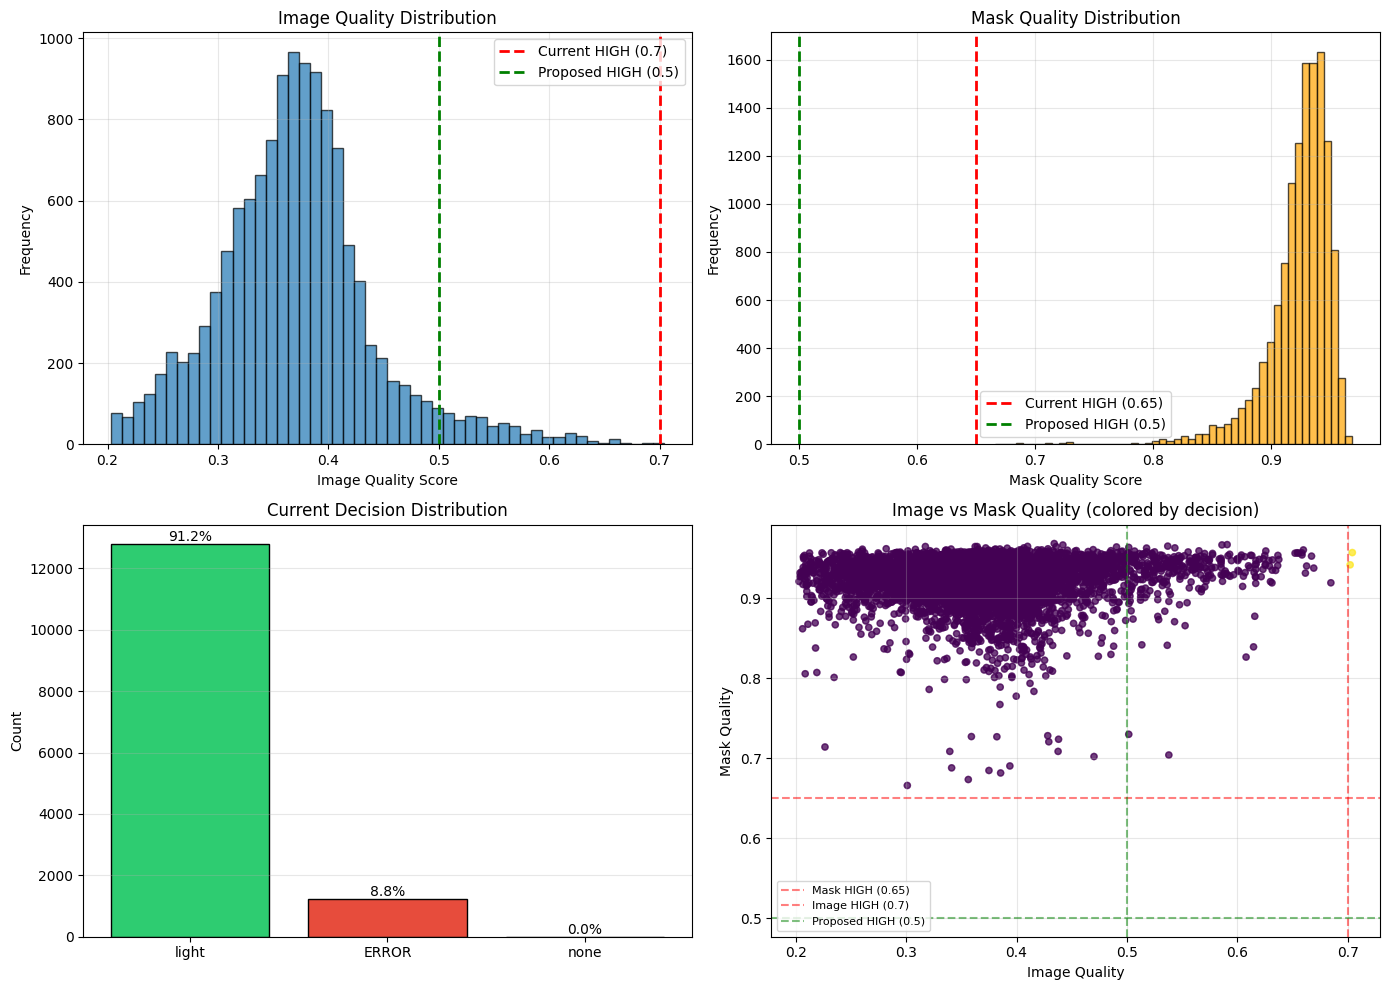

✅ Saved: quality_analysis.png


In [13]:
# ✅ COMPLETE QUALITY ANALYSIS
print("="*80)
print("📊 IMAGE QUALITY DISTRIBUTION")
print("="*80)
print(roi_train_df['image_quality'].describe())
print(f"\nPercentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = roi_train_df['image_quality'].quantile(p/100)
    print(f"  {p:>2}%: {val:.3f}")

print("\n" + "="*80)
print("📊 MASK QUALITY DISTRIBUTION")
print("="*80)
print(roi_train_df['mask_quality'].describe())
print(f"\nPercentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = roi_train_df['mask_quality'].quantile(p/100)
    print(f"  {p:>2}%: {val:.3f}")

# ✅ THRESHOLD ANALYSIS
print("\n" + "="*80)
print("🎯 CURRENT THRESHOLD POSITIONS")
print("="*80)
image_q_below_verylow = (roi_train_df['image_quality'] < 0.25).sum()
image_q_below_high = (roi_train_df['image_quality'] < 0.7).sum()
mask_q_below_medium = (roi_train_df['mask_quality'] < 0.45).sum()
mask_q_below_high = (roi_train_df['mask_quality'] < 0.65).sum()

print(f"Image quality < 0.25 (VERY_LOW): {image_q_below_verylow:>6} ({100*image_q_below_verylow/len(roi_train_df):>5.1f}%)")
print(f"Image quality < 0.70 (HIGH):      {image_q_below_high:>6} ({100*image_q_below_high/len(roi_train_df):>5.1f}%)")
print(f"Mask quality < 0.45 (MEDIUM):    {mask_q_below_medium:>6} ({100*mask_q_below_medium/len(roi_train_df):>5.1f}%)")
print(f"Mask quality < 0.65 (HIGH):      {mask_q_below_high:>6} ({100*mask_q_below_high/len(roi_train_df):>5.1f}%)")

# ✅ SIMULATE WITH NEW THRESHOLDS
print("\n" + "="*80)
print("🔮 SIMULATED DECISION WITH NEW THRESHOLDS")
print("="*80)

thresholds_to_test = [
    {"name": "Current", "img_high": 0.7, "mask_high": 0.65},
    {"name": "Moderate", "img_high": 0.55, "mask_high": 0.55},
    {"name": "Relaxed", "img_high": 0.5, "mask_high": 0.5},
    {"name": "Very Relaxed", "img_high": 0.45, "mask_high": 0.45},
]

for config in thresholds_to_test:
    baseline = ((roi_train_df['image_quality'] >= config['img_high']) &
                (roi_train_df['mask_quality'] >= config['mask_high'])).sum()
    non_baseline = len(roi_train_df) - baseline

    print(f"\n{config['name']:15} (img>={config['img_high']:.2f}, mask>={config['mask_high']:.2f}):")
    print(f"  Baseline: {baseline:>6} ({100*baseline/len(roi_train_df):>5.1f}%)")
    print(f"  Light:    {non_baseline:>6} ({100*non_baseline/len(roi_train_df):>5.1f}%)")

# ✅ CURRENT DECISION DISTRIBUTION
print("\n" + "="*80)
print("📊 CURRENT DECISION DISTRIBUTION")
print("="*80)
decision_counts = roi_train_df['decision'].value_counts()
for decision, count in decision_counts.items():
    print(f"  {decision:15} : {count:>6} ({100*count/len(roi_train_df):>5.1f}%)")

# ✅ ERROR ANALYSIS
print("\n" + "="*80)
print("⚠️ ERROR ANALYSIS")
print("="*80)
errors = roi_train_df[roi_train_df['error'].notna()]
print(f"Total errors: {len(errors)} ({100*len(errors)/len(roi_train_df):.1f}%)")

if len(errors) > 0:
    print(f"\nTop error reasons:")
    error_counts = errors['error'].value_counts().head(10)
    for error, count in error_counts.items():
        print(f"  • {error}: {count}")

# ✅ WARNING ANALYSIS
print("\n" + "="*80)
print("⚠️ WARNING ANALYSIS")
print("="*80)
warnings = roi_train_df[roi_train_df['warnings'].notna()]
print(f"Total with warnings: {len(warnings)} ({100*len(warnings)/len(roi_train_df):.1f}%)")

if len(warnings) > 0:
    print(f"\nTop warnings:")
    # Parse warnings (they are comma/pipe separated)
    all_warnings = []
    for w in warnings['warnings']:
        if pd.notna(w):
            all_warnings.extend(str(w).split('|'))

    from collections import Counter
    warning_counts = Counter(all_warnings)
    for warning, count in warning_counts.most_common(10):
        print(f"  • {warning.strip()}: {count}")

# ✅ OVERLAPPING DETECTION
print("\n" + "="*80)
print("🔄 OVERLAPPING DETECTION")
print("="*80)
overlapping = roi_train_df[roi_train_df['overlapping_detected'] == True]
print(f"Total overlapping: {len(overlapping)} ({100*len(overlapping)/len(roi_train_df):.1f}%)")
print(f"Solidity stats (overlapping cases):")
print(overlapping['overlapping_solidity'].describe())

# ✅ VISUALIZATION
print("\n" + "="*80)
print("📈 CREATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Image Quality Distribution
axes[0, 0].hist(roi_train_df['image_quality'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0.7, color='red', linestyle='--', linewidth=2, label='Current HIGH (0.7)')
axes[0, 0].axvline(0.5, color='green', linestyle='--', linewidth=2, label='Proposed HIGH (0.5)')
axes[0, 0].set_xlabel('Image Quality Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Image Quality Distribution')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Mask Quality Distribution
axes[0, 1].hist(roi_train_df['mask_quality'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].axvline(0.65, color='red', linestyle='--', linewidth=2, label='Current HIGH (0.65)')
axes[0, 1].axvline(0.5, color='green', linestyle='--', linewidth=2, label='Proposed HIGH (0.5)')
axes[0, 1].set_xlabel('Mask Quality Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Mask Quality Distribution')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Current Decision Distribution
decision_data = roi_train_df['decision'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#95a5a6']
axes[1, 0].bar(decision_data.index, decision_data.values, color=colors[:len(decision_data)], edgecolor='black')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Current Decision Distribution')
axes[1, 0].grid(alpha=0.3, axis='y')
for i, (decision, count) in enumerate(decision_data.items()):
    axes[1, 0].text(i, count, f'{100*count/len(roi_train_df):.1f}%', ha='center', va='bottom')

# Plot 4: Image vs Mask Quality Scatter
scatter = axes[1, 1].scatter(roi_train_df['image_quality'], roi_train_df['mask_quality'],
                            c=roi_train_df['decision'].map({'baseline': 0, 'light': 1, 'full': 2, 'none': 3}),
                            cmap='viridis', alpha=0.5, s=20)
axes[1, 1].axhline(0.65, color='red', linestyle='--', alpha=0.5, label='Mask HIGH (0.65)')
axes[1, 1].axvline(0.7, color='red', linestyle='--', alpha=0.5, label='Image HIGH (0.7)')
axes[1, 1].axhline(0.5, color='green', linestyle='--', alpha=0.5, label='Proposed HIGH (0.5)')
axes[1, 1].axvline(0.5, color='green', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Image Quality')
axes[1, 1].set_ylabel('Mask Quality')
axes[1, 1].set_title('Image vs Mask Quality (colored by decision)')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ROI_OUTPUT_PATH, 'quality_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: quality_analysis.png")

In [14]:
# Xem image quality theo từng cơ sở y tế
print("="*80)
print("📊 IMAGE QUALITY BY SOURCE")
print("="*80)

# Load toàn bộ ROI data (train + val + test)
roi_full_df = pd.concat([roi_train_df, roi_val_df, roi_test_df], ignore_index=True)

source_quality = roi_full_df.groupby('source')['image_quality'].agg([
    'count', 'mean', 'std', 'min', 'max',
    ('q25', lambda x: x.quantile(0.25)),
    ('q50', lambda x: x.quantile(0.50)),
    ('q75', lambda x: x.quantile(0.75)),
    ('q95', lambda x: x.quantile(0.95))
]).round(4)

print(source_quality)

# Xem phân bố
print("\n" + "="*80)
print("📋 SAMPLE COUNT BY SOURCE")
print("="*80)
print(roi_full_df['source'].value_counts())

📊 IMAGE QUALITY BY SOURCE
                count    mean     std     min     max    q25     q50     q75  \
source                                                                         
HAM10000         9142  0.3698  0.0705  0.2013  0.7042  0.327  0.3687  0.4043   
ISIC2018_Task3   9142  0.3698  0.0705  0.2013  0.7042  0.327  0.3687  0.4043   

                   q95  
source                  
HAM10000        0.4985  
ISIC2018_Task3  0.4985  

📋 SAMPLE COUNT BY SOURCE
source
ISIC2018_Task3    9142
HAM10000          9142
Name: count, dtype: int64


In [15]:
# Kiểm tra: Ảnh quality thấp có dẫn đến mask quality thấp không?
print("="*80)
print("📊 CORRELATION: Image Quality vs Mask Quality")
print("="*80)

correlation = roi_full_df['image_quality'].corr(roi_full_df['mask_quality'])
print(f"Correlation: {correlation:.4f}")

# Nếu correlation thấp → image quality thấp KHÔNG = mask quality thấp
# → Giảm threshold an toàn!

# Phân tích theo bins
roi_full_df['image_quality_bin'] = pd.cut(roi_full_df['image_quality'],
                                           bins=[0, 0.3, 0.4, 0.5, 0.6, 1.0],
                                           labels=['<0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6', '>0.6'])

print("\n" + "="*80)
print("🔍 MASK QUALITY BY IMAGE QUALITY BINS")
print("="*80)

mask_by_img_quality = roi_full_df.groupby('image_quality_bin', observed=True)['mask_quality'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(4)

print(mask_by_img_quality)

📊 CORRELATION: Image Quality vs Mask Quality
Correlation: 0.0375

🔍 MASK QUALITY BY IMAGE QUALITY BINS
                   count    mean     std     min     max
image_quality_bin                                       
<0.3                2558  0.9259  0.0222  0.7140  0.9639
0.3-0.4            10666  0.9227  0.0268  0.6658  0.9672
0.4-0.5             4160  0.9234  0.0293  0.7020  0.9685
0.5-0.6              746  0.9333  0.0264  0.7039  0.9672
>0.6                 154  0.9376  0.0223  0.8265  0.9605


In [16]:
# Kiểm tra: Có giảm threshold có dẫn đến miss overlapping cases không?
print("="*80)
print("🔄 OVERLAPPING DETECTION BY IMAGE QUALITY")
print("="*80)

overlapping_by_quality = roi_full_df.groupby('image_quality_bin', observed=True)['overlapping_detected'].agg([
    'count',
    ('overlapping_count', lambda x: x.sum()),
    ('overlapping_rate', lambda x: 100 * x.sum() / len(x))
]).round(2)

print(overlapping_by_quality)

🔄 OVERLAPPING DETECTION BY IMAGE QUALITY
                   count  overlapping_count  overlapping_rate
image_quality_bin                                            
<0.3                2558                  2              0.08
0.3-0.4            10666                 18              0.17
0.4-0.5             4160                 10              0.24
0.5-0.6              746                  4              0.54
>0.6                 154                  0              0.00


In [17]:
# Tạo validation samples từ mỗi quality tier
print("="*80)
print("✅ QUALITY TIER SAMPLES FOR MEDICAL REVIEW")
print("="*80)

for img_quality_threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    samples_below = roi_full_df[roi_full_df['image_quality'] < img_quality_threshold]
    samples_above = roi_full_df[roi_full_df['image_quality'] >= img_quality_threshold]

    print(f"\n📊 Threshold: {img_quality_threshold}")
    print(f"   Below: {len(samples_below):>6} ({100*len(samples_below)/len(roi_full_df):>5.1f}%)")
    print(f"   Above: {len(samples_above):>6} ({100*len(samples_above)/len(roi_full_df):>5.1f}%)")

    if len(samples_below) > 0:
        print(f"   Mask quality (below): {samples_below['mask_quality'].mean():.4f}")
    if len(samples_above) > 0:
        print(f"   Mask quality (above): {samples_above['mask_quality'].mean():.4f}")

✅ QUALITY TIER SAMPLES FOR MEDICAL REVIEW

📊 Threshold: 0.3
   Below:   2558 ( 12.8%)
   Above:  15726 ( 78.5%)
   Mask quality (below): 0.9259
   Mask quality (above): 0.9235

📊 Threshold: 0.4
   Below:  13224 ( 66.0%)
   Above:   5060 ( 25.3%)
   Mask quality (below): 0.9233
   Mask quality (above): 0.9253

📊 Threshold: 0.5
   Below:  17384 ( 86.8%)
   Above:    900 (  4.5%)
   Mask quality (below): 0.9233
   Mask quality (above): 0.9340

📊 Threshold: 0.6
   Below:  18130 ( 90.5%)
   Above:    154 (  0.8%)
   Mask quality (below): 0.9237
   Mask quality (above): 0.9376

📊 Threshold: 0.7
   Below:  18280 ( 91.3%)
   Above:      4 (  0.0%)
   Mask quality (below): 0.9239
   Mask quality (above): 0.9495


In [18]:
print("="*80)
print("🔬 GENERALIZATION RISK ANALYSIS")
print("="*80)

roi_full_df = pd.concat([roi_train_df, roi_val_df, roi_test_df], ignore_index=True)

# ✅ Current thresholds
print("\n📊 CURRENT THRESHOLDS STATISTICS")
print("="*80)

thresholds = {
    'IMAGE_QUALITY_HIGH': 0.50,
    'IMAGE_QUALITY_VERY_LOW': 0.25,
    'MASK_QUALITY_HIGH': 0.65,
}

print(f"Image Quality:")
print(f"  HIGH threshold: {thresholds['IMAGE_QUALITY_HIGH']}")
print(f"  Dataset mean:   {roi_full_df['image_quality'].mean():.4f}")
print(f"  Dataset std:    {roi_full_df['image_quality'].std():.4f}")
print(f"  Percentile of 0.5: {100*(roi_full_df['image_quality'] <= 0.5).sum()/len(roi_full_df):.1f}%")

print(f"\nMask Quality:")
print(f"  HIGH threshold: {thresholds['MASK_QUALITY_HIGH']}")
print(f"  Dataset mean:   {roi_full_df['mask_quality'].mean():.4f}")
print(f"  Dataset std:    {roi_full_df['mask_quality'].std():.4f}")
print(f"  Min value:      {roi_full_df['mask_quality'].min():.4f}")

# ⚠️ Scenario analysis
print("\n" + "="*80)
print("⚠️ SCENARIO ANALYSIS - WHAT IF DIFFERENT DATASET?")
print("="*80)

scenarios = [
    {
        'name': 'Smartphone Images (Low Quality)',
        'img_mean': 0.25,
        'img_std': 0.08,
        'mask_mean': 0.85,
        'mask_std': 0.10
    },
    {
        'name': 'Current ISIC + HAM10000',
        'img_mean': 0.37,
        'img_std': 0.07,
        'mask_mean': 0.92,
        'mask_std': 0.03
    },
    {
        'name': 'Professional Dermoscopy',
        'img_mean': 0.65,
        'img_std': 0.10,
        'mask_mean': 0.95,
        'mask_std': 0.02
    },
    {
        'name': 'Mixed Quality Dataset',
        'img_mean': 0.45,
        'img_std': 0.15,
        'mask_mean': 0.88,
        'mask_std': 0.08
    }
]

for scenario in scenarios:
    print(f"\n🔮 Scenario: {scenario['name']}")
    print(f"   Image Quality: mean={scenario['img_mean']:.2f}, std={scenario['img_std']:.2f}")
    print(f"   Mask Quality:  mean={scenario['mask_mean']:.2f}, std={scenario['mask_std']:.2f}")

    # Estimate % baseline with threshold 0.5
    # Assuming normal distribution
    from scipy.stats import norm

    img_baseline_pct = 100 * (1 - norm.cdf(0.5, scenario['img_mean'], scenario['img_std']))
    mask_baseline_pct = 100 * (1 - norm.cdf(0.65, scenario['mask_mean'], scenario['mask_std']))

    print(f"   → If threshold 0.5:")
    print(f"     - % samples >= 0.5: {img_baseline_pct:.1f}%")
    print(f"     - % samples >= 0.65 (mask): {mask_baseline_pct:.1f}%")

    if img_baseline_pct < 1:
        print(f"     ⚠️ WARNING: Almost no 'Baseline' samples!")
    elif img_baseline_pct > 50:
        print(f"     ⚠️ WARNING: Too many 'Baseline' samples (no preprocessing)!")
    else:
        print(f"     ✅ OK distribution")

# ✅ Robustness check
print("\n" + "="*80)
print("✅ MASK QUALITY ROBUSTNESS")
print("="*80)

print(f"\nCurrent mask quality vs image quality:")
print(f"  - Correlation: {roi_full_df['image_quality'].corr(roi_full_df['mask_quality']):.4f}")
print(f"  - This means: Mask quality is INDEPENDENT of image quality")
print(f"  - Risk: LOW (mask detection should work on ANY image quality)")

# Warning detection robustness
print(f"\nWarning detection:")
warnings_count = (roi_full_df['warnings'] != '').sum()
print(f"  - Samples with warnings: {warnings_count} ({100*warnings_count/len(roi_full_df):.1f}%)")
print(f"  - This is good: Even with threshold 0.5, we still warn users")

🔬 GENERALIZATION RISK ANALYSIS

📊 CURRENT THRESHOLDS STATISTICS
Image Quality:
  HIGH threshold: 0.5
  Dataset mean:   0.3698
  Dataset std:    0.0705
  Percentile of 0.5: 86.8%

Mask Quality:
  HIGH threshold: 0.65
  Dataset mean:   0.9239
  Dataset std:    0.0269
  Min value:      0.6658

⚠️ SCENARIO ANALYSIS - WHAT IF DIFFERENT DATASET?

🔮 Scenario: Smartphone Images (Low Quality)
   Image Quality: mean=0.25, std=0.08
   Mask Quality:  mean=0.85, std=0.10
   → If threshold 0.5:
     - % samples >= 0.5: 0.1%
     - % samples >= 0.65 (mask): 97.7%
     ⚠️ WARNING: Almost no 'Baseline' samples!

🔮 Scenario: Current ISIC + HAM10000
   Image Quality: mean=0.37, std=0.07
   Mask Quality:  mean=0.92, std=0.03
   → If threshold 0.5:
     - % samples >= 0.5: 3.2%
     - % samples >= 0.65 (mask): 100.0%
     ✅ OK distribution

🔮 Scenario: Professional Dermoscopy
   Image Quality: mean=0.65, std=0.10
   Mask Quality:  mean=0.95, std=0.02
   → If threshold 0.5:
     - % samples >= 0.5: 93.3%
  